# Quantum Fisher information — how precisely can a quantum state measure a parameter?

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien)

*Quantum Many-Body Simulation — Chapter 10 — Quantum metrology protocols*

## 1. Introduction and motivation

The most accurate machines humanity has ever built are *measuring* machines. An optical atomic clock loses less than one
second in the age of the universe. A gravitational-wave interferometer registers a change of length smaller than one
thousandth of a proton radius. A magnetometer built from atoms senses fields a billion times weaker than the Earth's.
All three do the same thing:

1. **prepare** a quantum state,
2. let an unknown physical quantity $\theta$ (a frequency, a phase, a magnetic field) **imprint** itself on that state,
3. **measure** the state and **estimate** $\theta$ from the clicks.

The question this notebook answers is: *given the state you prepared, what is the best precision any measurement could
possibly reach?* The answer is a single number attached to the state and to the way $\theta$ enters — the
**quantum Fisher information** $F_Q$ — and it bounds the error of every conceivable experiment through the
**quantum Cramér–Rao bound**

$$\Delta\theta \;\ge\; \frac{1}{\sqrt{M\,F_Q}},$$

where $M$ is the number of repetitions. Everything else in Chapter 10 — Ramsey interferometry, GHZ interferometry,
spin squeezing — is an attempt to make $F_Q$ as large as possible and then to actually reach the bound with a
realistic readout.

There is a second reason physicists care about $F_Q$. For $N$ qubits prepared independently the bound saturates at
$F_Q = N$; any state that beats it *must* be entangled. The quantum Fisher information is therefore an **entanglement
witness with an operational meaning**: it does not merely certify that a state is entangled, it says how much that
entanglement is worth in a laboratory.

**Road map.**

* **Sections 3–5 — classical estimation theory.** What an estimator is, what bias and variance mean, the Fisher
  information of a probability distribution, and the Cramér–Rao bound *derived* from the Cauchy–Schwarz inequality.
  We check every statement with simulated coin flips and show numerically that the maximum-likelihood estimator
  reaches the bound as the sample grows.
* **Sections 6–8 — the quantum step.** A measurement turns the state $\rho_\theta$ into a probability distribution
  $p(x\vert\theta)$, so every measurement has a classical Fisher information. The quantum Fisher information is the
  maximum over all measurements (Braunstein and Caves). For a pure state and unitary encoding we derive in full that
  $F_Q = 4\,\mathrm{Var}(G)$, and we implement it matrix-free.
* **Sections 9–10 — the two limits and a zoo of states.** Proofs of the standard quantum limit $F_Q\le N$ for product
  states and of the Heisenberg limit $F_Q\le N^2$ for everything, then measured values for product, GHZ, W, Dicke,
  cluster, Haar-random and ground states.
* **Sections 11–12 — directions and entanglement.** The $3\times3$ QFI matrix over $J_x,J_y,J_z$, the optimal
  generator direction as its largest eigenvector, and the entanglement-witness inequalities.
* **Sections 13–14 — reality.** QFI of noisy states (the mixed-state formula used here as a black box and derived
  in the next notebook) and QFI of a subsystem after particle loss, with a Schmidt-compression algorithm that makes
  losing one qubit as cheap as losing almost all of them.

### What you will learn

*Physics*

* what "precision" means mathematically, and why an unbiased estimator cannot do better than the Fisher information allows;
* why a product state of $N$ qubits gives $F_Q\le N$ (the standard quantum limit) and why no state gives more than $N^2$
  (the Heisenberg limit), with both proofs;
* which many-body states are metrologically useful, which are not, and why a highly entangled state can be *useless*
  (Haar-random states and cluster states are the instructive counter-examples);
* how noise and the loss of a single particle destroy the quantum advantage of a GHZ state.

*Numerical methods*

* the Cauchy–Schwarz proof of the Cramér–Rao bound, additivity of Fisher information, asymptotic efficiency of maximum likelihood;
* variance of a collective operator computed matrix-free in $O(N2^N)$ instead of $O(4^N)$;
* a $3\times3$ eigenvalue problem that replaces an optimisation over the sphere of generator directions;
* the symmetric-logarithmic-derivative formula as a black box, plus a rank-revealing **QR compression** that reduces an
  $O(8^{K})$ eigendecomposition to $O(8^{N-K})$ for the reduced state of $K$ kept qubits.

*Implementation practice*

* `jax.vmap` over Monte-Carlo repetitions, random states and parameter sweeps; explicit PRNG keys;
* `jax.jit` with static qubit indices and traced arrays; compile time separated from run time;
* validating a physical quantity three ways (matrix-free, dense, analytic) before trusting a single plot.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, PRNG keys;
* [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb): index notation as executable code;
* [05 — matrix-free operators](../ch03_matrix_free_engine/05_matrix_free_operators.ipynb): states as rank-$N$ tensors, `apply_gate`;
* [06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb): reduced density
  matrices, Schmidt decomposition;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb):
  density tensors, Kraus channels;
* [08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb): Born rule, sampling, shot noise;
* helpful: [22 — GHZ states and decoherence](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb).

**What comes next.** The notebook that follows,
[30 — QFI from the SLD: prepare, encode, estimate](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb),
derives the mixed-state formula we use here as a black box and builds the optimal measurement explicitly.
Then come the protocols: [31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb),
[32 — GHZ interferometry and the Heisenberg limit](../ch10_quantum_metrology_protocols/32_ghz_interferometry_heisenberg_limit.ipynb),
[33 — spin squeezing by one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb) and
[34 — the full one-axis-twisting to GHZ protocol](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb).
This notebook supplies the theory they all use.

**Conventions.** Qubit $q$ = tensor axis $q$; $\vert 0\rangle$ is the $+1$ eigenstate of $Z$. Collective spin operators are
$J_a=\tfrac12\sum_{q}\sigma^a_q$ for $a=x,y,z$, so a single qubit carries spin $1/2$ and $J_a$ has eigenvalues between
$-N/2$ and $+N/2$. The parameter is imprinted by $U(\theta)=e^{-i\theta G}$ with a Hermitian **generator** $G$; unless
said otherwise $G=J_{\mathbf n}=\mathbf n\cdot\mathbf J$ for a unit vector $\mathbf n$. With this convention the two
famous limits read $F_Q\le N$ and $F_Q\le N^2$ — no stray factors of $4$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and notebook helpers

From the engine we reuse the state constructors, `apply_gate` / `apply_gate_dm` (the einsum that applies a small matrix to
chosen axes of a state or density tensor), the Kraus channels, `apply_collective` (the matrix-free
$\sum_q P_q$), `qfi_pure`, `qfi_mixed`, `collective_dense`, `spin_moments`, and the Lanczos ground-state solver.
Everything specific to this notebook is built below from scratch.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP  (auto-generated from quantum_engine.py -- derived step by step in Part 0)
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "Ab,abc->aAc"          A = new (output) index of qubit 1
        N=4, q=(1,3)    :  "ABbd,abcd->aAcB"      A,B = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter; U carries (new letters)+(old letters of the targets); the output is psi's
    labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; m = Kraus index, summed!)
        "mAa, mBc, abcd -> AbBd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def purity(rho_mat):
    """Tr(rho^2): 1 for pure states, 1/d for the maximally mixed state in dimension d."""
    return jnp.real(jnp.trace(rho_mat @ rho_mat))

def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) sigma^-)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def qfi_pure(psi, P=Z, qubits=None):
    """Quantum Fisher information of a pure state for the phase imprinted by exp(-i theta J),
    J = (1/2) sum_q P_q:
        F_Q = 4 Var(J) = <G^2> - <G>^2   with G = sum_q P_q = 2J.
    Cramer-Rao: Delta theta >= 1/sqrt(M F_Q).  Product states F_Q <= N (standard quantum limit);
    GHZ: F_Q = N^2 (Heisenberg limit).   Matrix-free: |phi> = G|psi>,  <G^2> = <phi|phi>,  <G> = <psi|phi>."""
    phi = apply_collective(psi, P, qubits)
    return jnp.real(jnp.vdot(phi, phi)) - jnp.real(jnp.vdot(psi, phi)) ** 2

def qfi_mixed(rho_mat, G_mat, tol=1e-12):
    """QFI of a MIXED state (symmetric-logarithmic-derivative formula), rho = sum_m l_m |m><m|:
        F_Q = 2 sum_{m,n : l_m+l_n>0} (l_m - l_n)^2/(l_m + l_n) |<m|G|n>|^2       (G = generator, e.g. J).
    Reduces to 4 Var(G) for pure states.  Dense eigendecomposition -> use on small / reduced states."""
    lam, v = jnp.linalg.eigh(rho_mat)
    G = v.conj().T @ G_mat @ v
    num = (lam[:, None] - lam[None, :]) ** 2
    den = lam[:, None] + lam[None, :]
    return 2 * jnp.sum(jnp.where(den > tol, num / jnp.where(den > tol, den, 1.0), 0.0) * jnp.abs(G) ** 2)

def collective_dense(P, n):
    """Dense J = (1/2) sum_q P_q on n qubits (input of `qfi_mixed`), built from the matrix-free action
    on the basis vectors (vmap), exactly like `dense_hamiltonian`."""
    eye = jnp.eye(2 ** n, dtype=CDTYPE).reshape((2 ** n,) + (2,) * n)
    return 0.5 * jax.vmap(lambda e: apply_collective(e, P).reshape(-1))(eye).T

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers used throughout this notebook
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def timed(f, *args, budget=0.3, min_reps=5, max_reps=500):
    """Return (result, compile_time, best_run_time): the first call includes tracing+compilation, the rest do not.

    JAX is asynchronous, so every timed value must be forced with `block_until_ready` -- otherwise one
    measures the time to *dispatch* the work, not to do it.  We repeat for a fixed time `budget` and report
    the MINIMUM: on a shared machine the mean measures the operating system, the minimum measures the code.
    """
    t0 = time.time()
    out = jax.block_until_ready(f(*args))
    t_compile = time.time() - t0
    best, n, t_start = np.inf, 0, time.time()
    while n < min_reps or (time.time() - t_start < budget and n < max_reps):
        t0 = time.time()
        out = jax.block_until_ready(f(*args))
        best = min(best, time.time() - t0)
        n += 1
    return out, t_compile, best

## 3. Estimation theory: estimators, bias, variance

Before any quantum mechanics we need the classical machinery, because the quantum answer is a statement *about* it.

### 3.1 The setting

Nature holds a number $\theta$ that we cannot see. We can run an experiment whose outcome $x$ is random, with a
probability distribution $p(x\vert\theta)$ that we know as a *function of* $\theta$ — this function is the **statistical
model**. We run the experiment $M$ times, collect $x_1,\dots,x_M$, and compute a number

$$\hat\theta \;=\; T(x_1,\dots,x_M)$$

which we call an **estimator**. An estimator is just a formula applied to data; it is *not* the true value, and being a
function of random data it is itself a random variable. Two numbers describe how good it is:

$$\mathrm{bias}(\hat\theta)=\mathbb{E}_\theta[\hat\theta]-\theta,\qquad
  \mathrm{Var}(\hat\theta)=\mathbb{E}_\theta\!\left[(\hat\theta-\mathbb{E}_\theta[\hat\theta])^2\right],$$

and they combine into the **mean squared error**

$$\mathrm{MSE}(\hat\theta)=\mathbb{E}_\theta\!\left[(\hat\theta-\theta)^2\right]
  =\mathrm{Var}(\hat\theta)+\mathrm{bias}(\hat\theta)^2 . \tag{1}$$

*Proof of Eq. (1).* Write $\hat\theta-\theta=(\hat\theta-\mathbb{E}[\hat\theta])+(\mathbb{E}[\hat\theta]-\theta)$, square, and
take the expectation; the cross term is $2\,\mathbb{E}[\hat\theta-\mathbb{E}[\hat\theta]]\cdot\mathrm{bias}=0$. $\square$

An estimator is **unbiased** if its bias vanishes for *every* $\theta$. Unbiasedness is a convenience, not a virtue:
Eq. (1) shows that a slightly biased estimator with a much smaller variance can be the better one. But the bound we are
heading for — the Cramér–Rao bound — is a statement about unbiased estimators, so we keep track of the distinction.

### 3.2 The running example: a biased coin

The simplest model in existence: a coin lands heads ($x=1$) with unknown probability $\theta$ and tails ($x=0$) with
probability $1-\theta$, so $p(x\vert\theta)=\theta^x(1-\theta)^{1-x}$. Flip it $M$ times, count the heads $k$, and use

$$\hat\theta_{\text{mean}}=\frac{k}{M},\qquad\text{or}\qquad
  \hat\theta_{\text{Lap}}=\frac{k+1}{M+2}\quad\text{(Laplace's rule of succession)} .$$

The first is unbiased because $\mathbb{E}[k]=M\theta$; its variance is $\mathrm{Var}(k)/M^2=\theta(1-\theta)/M$.
The second is biased towards $1/2$. Let us simulate both.

In [4]:
# ==============================================================================
# STEP 1: the coin experiment -- two estimators, measured bias and variance
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
THETA_COIN = 0.30          # the "unknown" probability of heads
N_REPEAT   = 20_000        # how many independent experiments we simulate (Monte-Carlo sample size)
M_LIST     = (10, 100, 1000)   # number of flips per experiment
# -----------------------------------------------------------------------------


def coin_experiments(key, theta, M, n_repeat):
    """Simulate `n_repeat` independent experiments of `M` Bernoulli(theta) flips; return the head counts.

    MATH   k ~ Binomial(M, theta).
    JAX    one (n_repeat, M) array of booleans, summed along the flip axis: no Python loop at all.
    """
    flips = jax.random.bernoulli(key, theta, (n_repeat, M))
    return jnp.sum(flips, axis=1)


print(f"true theta = {THETA_COIN}\n")
print(f"{'M':>6s} | {'bias(k/M)':>12s} {'Var(k/M)':>12s} {'theta(1-theta)/M':>18s} | "
      f"{'bias(Laplace)':>14s} {'Var(Laplace)':>13s}")
for M in M_LIST:
    k = coin_experiments(jax.random.PRNGKey(0), THETA_COIN, M, N_REPEAT)
    mean_est = k / M
    lap_est = (k + 1) / (M + 2)
    var_theory = THETA_COIN * (1 - THETA_COIN) / M
    print(f"{M:6d} | {float(jnp.mean(mean_est)) - THETA_COIN:+12.5f} {float(jnp.var(mean_est)):12.3e} "
          f"{var_theory:18.3e} | {float(jnp.mean(lap_est)) - THETA_COIN:+14.5f} {float(jnp.var(lap_est)):13.3e}")
    # the sample mean is unbiased; the Monte-Carlo error of a mean over N_REPEAT samples is sqrt(Var/N_REPEAT)
    assert abs(float(jnp.mean(mean_est)) - THETA_COIN) < 5 * np.sqrt(var_theory / N_REPEAT)

true theta = 0.3

     M |    bias(k/M)     Var(k/M)   theta(1-theta)/M |  bias(Laplace)  Var(Laplace)


    10 |     +0.00299    2.127e-02          2.100e-02 |       +0.03582     1.477e-02


   100 |     -0.00014    2.123e-03          2.100e-03 |       +0.00379     2.040e-03


  1000 |     +0.00023    2.098e-04          2.100e-04 |       +0.00063     2.090e-04


The measured variance of the sample mean matches $\theta(1-\theta)/M$ to three digits, and its bias is zero within the
Monte-Carlo error. Laplace's estimator is visibly biased — at $M=10$ by about $+0.036$, shrinking like $1/M$ — yet its
variance is *smaller* than that of the sample mean at every $M$. That is the bias–variance trade-off of Eq. (1) in one line
of output, and the reason the coming bound has to say "unbiased" out loud.

## 4. The classical Fisher information

### 4.1 The score

Fix the data $x$ and vary $\theta$: the function $\theta\mapsto p(x\vert\theta)$ tells us how *surprised* we should be by
the data we got, for each hypothetical $\theta$. Its logarithmic derivative,

$$s(x,\theta)=\frac{\partial}{\partial\theta}\log p(x\vert\theta)=\frac{\partial_\theta p(x\vert\theta)}{p(x\vert\theta)},$$

is called the **score**. It measures how strongly the outcome $x$ discriminates between $\theta$ and $\theta+d\theta$:
if $p(x\vert\theta)$ barely changes with $\theta$, the outcome $x$ carries almost no information about $\theta$.

The score has mean zero:

$$\mathbb{E}_\theta[s]=\sum_x p(x\vert\theta)\,\frac{\partial_\theta p(x\vert\theta)}{p(x\vert\theta)}
  =\sum_x\partial_\theta p(x\vert\theta)=\partial_\theta\!\sum_x p(x\vert\theta)=\partial_\theta 1=0 . \tag{2}$$

(We may exchange sum and derivative because the sum is finite, or under mild regularity for continuous $x$.)

### 4.2 Definition and the two formulas

The **Fisher information** of the model at $\theta$ is the variance of the score, which by Eq. (2) is its second moment:

$$I(\theta)\;=\;\mathrm{Var}_\theta[s]\;=\;\mathbb{E}_\theta\!\left[s^2\right]
  \;=\;\sum_x\frac{\left(\partial_\theta p(x\vert\theta)\right)^2}{p(x\vert\theta)} . \tag{3}$$

Equation (3) is the working formula: sum the squared sensitivity of each outcome probability, divided by that probability.
There is an equivalent "curvature" formula,

$$I(\theta)=-\,\mathbb{E}_\theta\!\left[\frac{\partial^2}{\partial\theta^2}\log p(x\vert\theta)\right], \tag{4}$$

*Proof of Eq. (4).* $\partial_\theta^2\log p=\partial_\theta(\partial_\theta p/p)=\partial^2_\theta p/p-(\partial_\theta p/p)^2$.
Taking the expectation, the first term is $\sum_x\partial^2_\theta p=\partial_\theta^2\sum_x p=0$ and the second is $\mathbb{E}[s^2]=I$. $\square$

Equation (4) explains the name: $I(\theta)$ is the average curvature of the log-likelihood at its peak. A sharply peaked
likelihood means a well-determined $\theta$.

### 4.3 Additivity over repetitions

If we repeat the experiment $M$ times independently, the data are $x_1,\dots,x_M$ and
$p(x_1..x_M\vert\theta)=\prod_j p(x_j\vert\theta)$, so the score is a **sum of independent scores**,
$s_{\text{tot}}=\sum_j s(x_j,\theta)$. Variances of independent variables add:

$$I_M(\theta)=M\,I(\theta). \tag{5}$$

Equation (5) is the origin of the $1/\sqrt M$ improvement of precision with the number of repetitions.

### 4.4 The coin, again

For the Bernoulli model $\log p=x\log\theta+(1-x)\log(1-\theta)$, hence $s=x/\theta-(1-x)/(1-\theta)$ and

$$I(\theta)=\frac{(1-\theta)^2}{\theta^2}\theta+\frac{\theta^2}{(1-\theta)^2}(1-\theta)
  =\frac{1-\theta}{\theta}+\frac{\theta}{1-\theta}=\frac{1}{\theta(1-\theta)} . \tag{6}$$

Two sanity checks: $I$ blows up as $\theta\to0$ or $1$ (a coin that almost never shows heads pins its bias down very
precisely once it does), and it is smallest at $\theta=1/2$ (a fair-looking coin is the hardest to characterise).
We verify Eq. (3) numerically, once with a finite-difference derivative and once with automatic differentiation.

In [5]:
# ==============================================================================
# STEP 2: classical Fisher information from its definition, Eq. (3)
# ==============================================================================
def fisher_information(prob_fn, theta, eps=1e-6, tol=1e-14):
    """Classical Fisher information of a discrete model, Eq. (3), with a central-difference derivative.

    MATH   I(theta) = sum_x (d p(x|theta)/d theta)^2 / p(x|theta)      [terms with p = 0 are dropped]
    ARGS   prob_fn: theta -> array of probabilities p(x|theta) summing to 1.
    JAX    `jnp.where` guards the division so that zero-probability outcomes contribute exactly 0
           (and produce no NaN inside a jit-ted/vmapped computation).
    """
    p = prob_fn(theta)
    dp = (prob_fn(theta + eps) - prob_fn(theta - eps)) / (2 * eps)
    ok = p > tol
    return jnp.sum(jnp.where(ok, dp ** 2 / jnp.where(ok, p, 1.0), 0.0))


def fisher_information_ad(prob_fn, theta, tol=1e-14):
    """The same quantity with an EXACT derivative from forward-mode automatic differentiation.

    JAX   `jax.jacfwd` pushes a tangent of the (real) input through `prob_fn`; no step size, no truncation error.
    """
    p = prob_fn(theta)
    dp = jax.jacfwd(prob_fn)(theta)
    ok = p > tol
    return jnp.sum(jnp.where(ok, dp ** 2 / jnp.where(ok, p, 1.0), 0.0))


def coin_probs(theta):
    """p(x|theta) for one Bernoulli flip, as the array [p(tails), p(heads)]."""
    return jnp.stack([1 - theta, theta])


# --- CHECKPOINT: numerical Fisher information vs the analytic Eq. (6) ------------------
print(f"{'theta':>6s} | {'I (finite diff)':>16s} {'I (jacfwd)':>13s} {'1/(theta(1-theta))':>20s}")
for th in (0.1, 0.3, 0.5, 0.7, 0.9):
    i_fd = float(fisher_information(coin_probs, th))
    i_ad = float(fisher_information_ad(coin_probs, th))
    i_ex = 1.0 / (th * (1 - th))
    print(f"{th:6.2f} | {i_fd:16.8f} {i_ad:13.8f} {i_ex:20.8f}")
    assert abs(i_ad - i_ex) < 1e3 * TOL and abs(i_fd - i_ex) < 1e-5

 theta |  I (finite diff)    I (jacfwd)   1/(theta(1-theta))


  0.10 |      11.11111111   11.11111111          11.11111111
  0.30 |       4.76190476    4.76190476           4.76190476
  0.50 |       4.00000000    4.00000000           4.00000000
  0.70 |       4.76190476    4.76190476           4.76190476
  0.90 |      11.11111111   11.11111111          11.11111111


Both derivatives reproduce Eq. (6). Automatic differentiation is exact to machine precision; the finite difference agrees
to a few times $10^{-10}$, which is the usual compromise of a central difference (truncation error $O(\epsilon^2)$ plus
round-off $O(\epsilon^{-1}\cdot 10^{-16})$; the sum of the two is smallest near $\epsilon\approx10^{-5}$, so the
$\epsilon=10^{-6}$ used above is already on the round-off side of the optimum).

> **Numerical practice.** Whenever you need $\partial_\theta$ of something a JAX function computes, reach for
> `jax.jacfwd` / `jax.grad` first: no step size to tune, no cancellation. Keep the finite difference as an *independent*
> check — the two routes fail in completely different ways, so their agreement is real evidence.

## 5. The Cramér–Rao bound, derived

### 5.1 Statement and proof

**Theorem (Cramér–Rao).** Let $\hat\theta=T(x)$ be an unbiased estimator of $\theta$ in a model with Fisher
information $I(\theta)>0$. Then

$$\mathrm{Var}(\hat\theta)\;\ge\;\frac{1}{I(\theta)} . \tag{7}$$

*Proof.* Consider the covariance of the estimator with the score. Since $\mathbb{E}[s]=0$ by Eq. (2),

$$\mathrm{Cov}(T,s)=\mathbb{E}[T\,s]-\mathbb{E}[T]\,\mathbb{E}[s]=\sum_x T(x)\,p(x\vert\theta)\,\frac{\partial_\theta p(x\vert\theta)}{p(x\vert\theta)}
  =\sum_x T(x)\,\partial_\theta p(x\vert\theta)=\partial_\theta\!\sum_x T(x)p(x\vert\theta)=\partial_\theta\,\mathbb{E}[T] .$$

Unbiasedness means $\mathbb{E}[T]=\theta$ for all $\theta$, so the right-hand side is exactly $1$:

$$\mathrm{Cov}(T,s)=1 .$$

Now apply the Cauchy–Schwarz inequality to the two zero-mean random variables $T-\mathbb{E}[T]$ and $s$:

$$\big(\mathrm{Cov}(T,s)\big)^2\;\le\;\mathrm{Var}(T)\,\mathrm{Var}(s) .$$

The left side is $1$ and $\mathrm{Var}(s)=I(\theta)$ by definition, so $1\le\mathrm{Var}(T)\,I(\theta)$, which is Eq. (7). $\square$

The proof also tells us **when the bound is tight**: Cauchy–Schwarz is an equality precisely when the two variables are
proportional, i.e. when

$$T(x)-\theta \;=\; \frac{1}{I(\theta)}\,s(x,\theta)\qquad\text{for all }x . \tag{8}$$

A model admitting such an estimator is called *efficient*. Applying Eq. (7) to the $M$-sample model, whose Fisher
information is $M I(\theta)$ by Eq. (5), gives the form every experimentalist quotes:

$$\Delta\theta\;=\;\sqrt{\mathrm{Var}(\hat\theta)}\;\ge\;\frac{1}{\sqrt{M\,I(\theta)}} , \tag{9}$$

for any estimator $\hat\theta=T(x_1,\dots,x_M)$ that is unbiased as a function of the whole data set.

### 5.2 The small print: regularity and local unbiasedness

Two steps of the proof are assumptions in disguise, and both are violated by models a student will meet.

1. **Regularity.** We differentiated under the sum twice, in Eq. (2) and in the covariance computation. This is legitimate
   when the *set of possible outcomes does not depend on $\theta$* and $p(x\vert\theta)$ is differentiable there. If some
   $p(x\vert\theta)$ hits $0$ — as the fringe model of Eq. (10) does at $\theta=0$ and $\theta=\pi$ — the score is undefined
   for that outcome, $I(\theta)$ need not be the limit of its neighbours, and the bound does not apply at that point.
   Exercise 2 examines exactly this situation.
2. **How much unbiasedness.** The proof used $\mathbb{E}[T]=\theta$ only to conclude $\partial_\theta\mathbb{E}[T]=1$ at the
   one value of $\theta$ we are bounding. So *local* unbiasedness — $\mathbb{E}[T]=\theta$ and $\partial_\theta\mathbb{E}[T]=1$
   at that point — already suffices; global unbiasedness for all $\theta$ is a stronger condition than the theorem needs.
   This matters in practice: an estimator that is unbiased only near the working point, like the maximum-likelihood
   estimator at large $M$, is still constrained by Eq. (9) there.

### 5.3 The coin is efficient; a nonlinear model is only asymptotically efficient

For the coin, the score of $M$ flips is $s_{\text{tot}}=k/\theta-(M-k)/(1-\theta)=(k-M\theta)/(\theta(1-\theta))$, and
$I_M=M/(\theta(1-\theta))$, so $s_{\text{tot}}/I_M=k/M-\theta$: Eq. (8) holds exactly with $T=k/M$. That is why the
measured variance in Section 3 sat *on* the bound rather than above it.

Efficiency at finite $M$ is the exception. Take the model we will meet again in every interferometer of this chapter: a binary outcome
whose probability is

$$p(+\vert\theta)=\frac{1+\cos\theta}{2},\qquad p(-\vert\theta)=\frac{1-\cos\theta}{2} . \tag{10}$$

Its Fisher information is, from Eq. (3),

$$I(\theta)=\frac{\left(\tfrac12\sin\theta\right)^2}{p_+}+\frac{\left(\tfrac12\sin\theta\right)^2}{p_-}
  =\frac{\sin^2\theta}{4}\cdot\frac{p_++p_-}{p_+p_-}
  =\frac{\sin^2\theta}{4}\cdot\frac{4}{\sin^2\theta}=1 \tag{11}$$

(using $\partial_\theta p_\pm=\mp\tfrac12\sin\theta$ and $p_+p_-=(1-\cos^2\theta)/4=\sin^2\theta/4$) — independent of
$\theta$, except at $\theta=0$ and $\theta=\pi$, where one outcome has probability zero and the regularity condition of
Section 5.2 fails. The **maximum-likelihood
estimator** maximises $\log p(\text{data}\vert\theta)=k\log p_++(M-k)\log p_-$ over $\theta$; setting the derivative to zero
gives $\cos\hat\theta=2k/M-1$, i.e.

$$\hat\theta_{\text{ML}}=\arccos\!\left(\frac{2k}{M}-1\right) .$$

Because $\arccos$ is nonlinear, $\hat\theta_{\text{ML}}$ is *biased* at finite $M$ and does not satisfy Eq. (8) exactly.
The general theorem — quoted, not proved here — says that under regularity conditions the maximum-likelihood estimator is
**consistent and asymptotically efficient**: its bias falls like $1/M$ and $M\,\mathrm{Var}(\hat\theta_{\text{ML}})\to1/I(\theta)$.
The simulation below measures both.

In [6]:
# ==============================================================================
# STEP 3: maximum likelihood saturates the Cramer-Rao bound as M grows
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
THETA_TRUE = np.pi / 2          # working point: p(+) = 1/2, the steepest part of the fringe
M_GRID     = (4, 10, 30, 100, 300, 1000, 3000)
N_EXP      = 40_000             # independent experiments per M
# -----------------------------------------------------------------------------


def ramsey_probs(theta):
    """The two-outcome model of Eq. (10) as an array [p(+), p(-)]."""
    return jnp.stack([(1 + jnp.cos(theta)) / 2, (1 - jnp.cos(theta)) / 2])


I_ramsey = float(fisher_information_ad(ramsey_probs, THETA_TRUE))
print(f"Fisher information of the model, Eq. (11), at theta = pi/2 : I = {I_ramsey:.10f}  (analytic: 1)")
assert abs(I_ramsey - 1.0) < 1e3 * TOL

rows = []
p_plus = float(ramsey_probs(THETA_TRUE)[0])
print(f"\n{'M':>6s} | {'bias':>10s} {'M x Var':>10s} {'1/I = 1':>9s} {'ratio':>7s}")
for M in M_GRID:
    key = jax.random.PRNGKey(1)
    k = jnp.sum(jax.random.bernoulli(key, p_plus, (N_EXP, M)), axis=1)     # number of '+' outcomes
    est = jnp.arccos(jnp.clip(2 * k / M - 1, -1.0, 1.0))                    # maximum-likelihood estimate
    bias = float(jnp.mean(est)) - THETA_TRUE
    mvar = float(jnp.var(est)) * M
    rows.append((M, bias, mvar))
    print(f"{M:6d} | {bias:+10.5f} {mvar:10.4f} {1 / I_ramsey:9.4f} {mvar * I_ramsey:7.3f}")
assert abs(rows[-1][2] * I_ramsey - 1.0) < 0.05

Fisher information of the model, Eq. (11), at theta = pi/2 : I = 1.0000000000  (analytic: 1)

     M |       bias    M x Var   1/I = 1   ratio


     4 |   +0.00319     1.8043    1.0000   1.804


    10 |   -0.00136     1.1368    1.0000   1.137


    30 |   -0.00101     1.0476    1.0000   1.048


   100 |   -0.00071     1.0140    1.0000   1.014


   300 |   -0.00003     0.9951    1.0000   0.995


  1000 |   +0.00019     0.9982    1.0000   0.998


  3000 |   -0.00003     1.0031    1.0000   1.003


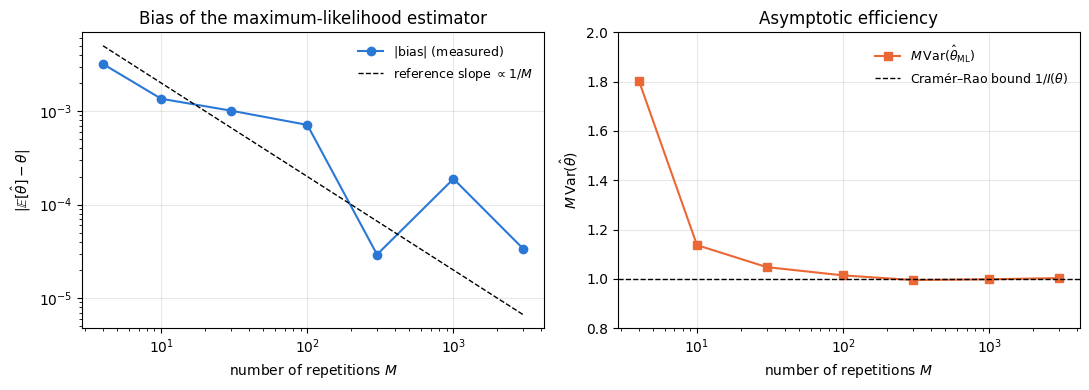

In [7]:
# ==============================================================================
# FIGURE: convergence of the maximum-likelihood estimator to the Cramer-Rao bound
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.0))
Ms = np.array([r[0] for r in rows], dtype=float)
axes[0].loglog(Ms, np.abs([r[1] for r in rows]), "o-", color=PALETTE[0], label=r"$\vert\mathrm{bias}\vert$ (measured)")
axes[0].loglog(Ms, 0.02 / Ms, "k--", lw=1, label=r"reference slope $\propto 1/M$")
axes[0].set_xlabel("number of repetitions $M$"); axes[0].set_ylabel(r"$\vert\mathbb{E}[\hat\theta]-\theta\vert$")
axes[0].set_title("Bias of the maximum-likelihood estimator"); axes[0].legend(fontsize=9)

axes[1].semilogx(Ms, [r[2] for r in rows], "s-", color=PALETTE[1], label=r"$M\,\mathrm{Var}(\hat\theta_{\rm ML})$")
axes[1].axhline(1 / I_ramsey, color="k", ls="--", lw=1, label=r"Cramér–Rao bound $1/I(\theta)$")
axes[1].set_xlabel("number of repetitions $M$"); axes[1].set_ylabel(r"$M\,\mathrm{Var}(\hat\theta)$")
axes[1].set_ylim(0.8, 2.0)
axes[1].set_title("Asymptotic efficiency"); axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

Both panels behave as the theory demands. The bias falls on the reference line $\propto 1/M$ until it disappears into the
Monte-Carlo noise floor of $40\,000$ experiments. The scaled variance $M\,\mathrm{Var}$ starts well *above* the bound at
$M=4$ — a handful of flips is simply not enough to invert a cosine reliably — and settles onto $1/I(\theta)=1$ from about
$M\approx30$ onwards, staying within a percent of it thereafter. The Cramér–Rao bound is not merely a bound: for a
well-behaved model it is the *achievable* precision, given enough data.

> **Common pitfall.** "My estimator beat the Cramér–Rao bound" almost always means "my estimator is biased". At $M=4$
> above one can indeed construct estimators with a smaller variance than $1/(MI)$ — they shrink towards a fixed guess and
> pay for it with bias. Eq. (7) constrains the variance only for *unbiased* estimators; Eq. (1) is what you should minimise.

## 6. Going quantum: a measurement turns a state into a probability distribution

Now the model $p(x\vert\theta)$ stops being given and starts being *chosen*. The experiment is:

$$\rho\;\xrightarrow[\text{encoding}]{\;U(\theta)=e^{-i\theta G}\;}\;\rho_\theta=U(\theta)\,\rho\,U^\dagger(\theta)
  \;\xrightarrow[\text{measurement}]{\;\{E_x\}\;}\;p(x\vert\theta)=\mathrm{Tr}\!\left(\rho_\theta E_x\right).$$

The middle step is fixed by the physics of the device: a magnetic field $B$ acting for a time $t$ rotates the spins, so
$\theta = \gamma B t$ with $G=J_z$; an optical path-length difference gives $\theta=2\pi \Delta L/\lambda$; and a clock
compares an atomic frequency with a laser, so $\theta=(\omega_{\text{atom}}-\omega_{\text{laser}})t$. The last step is what
we choose: a **POVM**, i.e. a set of positive operators $E_x\succeq0$ with $\sum_x E_x=\mathbb 1$ (see
[08 — measurements](../ch03_matrix_free_engine/08_measurements.ipynb)). A projective measurement in some basis
$\{\vert x\rangle\}$ is the special case $E_x=\vert x\rangle\langle x\vert$.

Every choice of POVM yields a classical model and therefore a classical Fisher information

$$I(\theta;\{E_x\})=\sum_x\frac{\left(\partial_\theta\mathrm{Tr}(\rho_\theta E_x)\right)^2}{\mathrm{Tr}(\rho_\theta E_x)},$$

and, by the Cramér–Rao bound, a precision limit $\Delta\theta\ge1/\sqrt{M\,I(\theta;\{E_x\})}$. A *bad* measurement gives
$I=0$: for a GHZ state with $G=J_z$, measuring every qubit along $z$ produces outcome statistics that do not depend on
$\theta$ at all, so no estimator can extract the phase from that data. A *good* measurement makes $I$ as large as
possible. The natural question is how large it can be.

### 6.1 The quantum Fisher information

**Definition.** The **quantum Fisher information** of the family $\rho_\theta$ is

$$F_Q[\rho_\theta]\;=\;\max_{\{E_x\}}\;I(\theta;\{E_x\}), \tag{12}$$

the maximum of the classical Fisher information over all POVMs. It depends on the state and on how $\theta$ enters, but
**not** on the measurement — the optimisation has been done once and for all.

**Theorem (Braunstein and Caves 1994).** The maximum in Eq. (12) exists, equals

$$F_Q=\mathrm{Tr}\!\left(\rho_\theta L_\theta^2\right)
  \qquad\text{where } L_\theta \text{ solves } \partial_\theta\rho_\theta=\tfrac12\left(L_\theta\rho_\theta+\rho_\theta L_\theta\right),$$

and is attained by the projective measurement in the eigenbasis of the Hermitian operator $L_\theta$, called the
**symmetric logarithmic derivative** (SLD). The optimal measurement is *local* in the parameter: $L_\theta$ depends on
$\theta$, so the basis that saturates the bound at one working point need not saturate it at another. An experiment
reaches $F_Q$ by using a rough estimate of $\theta$ to choose the basis and then refining — adaptively, or by working at
a fixed operating point as the interferometers of notebooks 31 and 32 do. Consequently

$$\Delta\theta\;\ge\;\frac{1}{\sqrt{M\,I(\theta;\{E_x\})}}\;\ge\;\frac{1}{\sqrt{M\,F_Q}} , \tag{13}$$

the **quantum Cramér–Rao bound**.

We take this theorem on trust *here* and pay the debt in the next notebook,
[30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb), which
solves the equation for $L_\theta$ line by line, evaluates $\mathrm{Tr}(\rho L^2)$, builds the optimal measurement
explicitly and shows numerically that its classical Fisher information equals $F_Q$ while other measurements fall short.
For the rest of *this* notebook we only need one consequence of it, which we derive from scratch right now.

## 7. Pure states and unitary encoding: $F_Q=4\,\mathrm{Var}(G)$

Take a pure initial state $\rho=\vert\psi\rangle\langle\psi\vert$ and the unitary encoding
$\vert\psi_\theta\rangle=e^{-i\theta G}\vert\psi\rangle$. We prove

$$\boxed{\;F_Q\;=\;4\left(\langle\psi\vert G^2\vert\psi\rangle-\langle\psi\vert G\vert\psi\rangle^2\right)\;=\;4\,\mathrm{Var}_\psi(G)\;} \tag{14}$$

in two independent ways.

### 7.1 Route 1: straight from the SLD

For a pure state $\rho_\theta^2=\rho_\theta$. Differentiate:

$$\partial_\theta\rho=\left(\partial_\theta\rho\right)\rho+\rho\left(\partial_\theta\rho\right)
  =\tfrac12\left[(2\partial_\theta\rho)\rho+\rho(2\partial_\theta\rho)\right],$$

which is exactly the defining equation of the SLD with

$$L=2\,\partial_\theta\rho .$$

The derivative of the encoded state is a commutator,

$$\partial_\theta\rho_\theta=\partial_\theta\left(e^{-i\theta G}\rho\,e^{i\theta G}\right)=-i\left[G,\rho_\theta\right],$$

so, writing everything at $\theta=0$ (nothing depends on $\theta$, as we check below) and abbreviating
$g=\langle G\rangle$, $g_2=\langle G^2\rangle$, $\rho=\vert\psi\rangle\langle\psi\vert$:

$$\begin{aligned}
(\partial_\theta\rho)^2 &= -\left(G\rho-\rho G\right)\left(G\rho-\rho G\right)
  = -\left(G\rho G\rho-G\rho\rho G-\rho G G\rho+\rho G\rho G\right)\\
 &= -\left(g\,G\rho-G\rho G-g_2\,\rho+g\,\rho G\right),
\end{aligned}$$

where we used $\rho\rho=\rho$ and $\rho G\rho=g\,\rho$. Taking $\mathrm{Tr}(\rho\;\cdot\;)$ term by term, with
$\mathrm{Tr}(\rho G\rho)=g$, $\mathrm{Tr}(\rho G\rho G)=g^2$, $\mathrm{Tr}(\rho\rho)=1$ and $\mathrm{Tr}(\rho\rho G)=g$:

$$\mathrm{Tr}\!\left(\rho\,(\partial_\theta\rho)^2\right)=-\left(g^2-g^2-g_2+g^2\right)=g_2-g^2=\mathrm{Var}(G).$$

Hence $F_Q=\mathrm{Tr}(\rho L^2)=4\,\mathrm{Tr}\!\left(\rho(\partial_\theta\rho)^2\right)=4\,\mathrm{Var}(G)$, which is Eq. (14). $\square$

### 7.2 Route 2: the overlap (fidelity) expansion

The quantum Fisher information is also the curvature of the **fidelity** between neighbouring states — the standard
relation, derived in notebook 30,

$$F_Q=\lim_{d\theta\to0}\frac{8\left(1-\sqrt{F(\rho_\theta,\rho_{\theta+d\theta})}\right)}{d\theta^2},\qquad
  F(\vert\psi\rangle,\vert\phi\rangle)=\left\vert\langle\psi\vert\phi\rangle\right\vert^2 . \tag{15}$$

For pure states with unitary encoding the overlap is computable by hand. Expand the exponential to second order:

$$\langle\psi\vert e^{-i\,d\theta\,G}\vert\psi\rangle
 =1-i\,d\theta\,\langle G\rangle-\frac{d\theta^2}{2}\langle G^2\rangle+O(d\theta^3).$$

Its squared modulus is (real part squared plus imaginary part squared)

$$\begin{aligned}
\left\vert\langle\psi\vert\psi_{d\theta}\rangle\right\vert^2
 &=\left(1-\frac{d\theta^2}{2}\langle G^2\rangle\right)^2+d\theta^2\langle G\rangle^2+O(d\theta^3)\\
 &=1-d\theta^2\left(\langle G^2\rangle-\langle G\rangle^2\right)+O(d\theta^3)
  =1-d\theta^2\,\mathrm{Var}(G)+O(d\theta^3).
\end{aligned}$$

Therefore $\sqrt{F}=1-\tfrac12 d\theta^2\mathrm{Var}(G)+O(d\theta^3)$ and Eq. (15) gives
$F_Q=8\cdot\tfrac12\mathrm{Var}(G)=4\,\mathrm{Var}(G)$, the same answer. $\square$

### 7.3 Two immediate corollaries

**$F_Q$ does not depend on $\theta$.** $\mathrm{Var}_{\psi_\theta}(G)=\mathrm{Var}_\psi(e^{i\theta G}Ge^{-i\theta G})=\mathrm{Var}_\psi(G)$
because $G$ commutes with its own exponential. So we may evaluate everything at $\theta=0$ and never encode at all when
we only want $F_Q$ — a large practical saving.

**A global phase is invisible.** Replacing $G\to G+c\,\mathbb 1$ changes $U$ by a phase and leaves $\mathrm{Var}(G)$
unchanged. Only the *spread* of the generator matters, never its mean.

### 7.4 A worked check on one qubit

One qubit, $\vert\psi\rangle=\vert+\rangle=(\vert0\rangle+\vert1\rangle)/\sqrt2$, generator $G=J_z=Z/2$. Then
$\langle J_z\rangle=0$ and $J_z^2=\mathbb 1/4$, so $\mathrm{Var}(J_z)=1/4$ and Eq. (14) gives $F_Q=1$.
Is that reachable? Encode and measure along $x$:

$$\vert\psi_\theta\rangle=\frac{e^{-i\theta/2}\vert0\rangle+e^{+i\theta/2}\vert1\rangle}{\sqrt2},\qquad
p(\pm\vert\theta)=\left\vert\langle\pm\vert\psi_\theta\rangle\right\vert^2=\frac{1\pm\cos\theta}{2},$$

which is precisely the model of Eq. (10) whose Fisher information we computed to be $I=1$ for every $\theta$.
So the simplest interferometer in physics saturates the quantum Cramér–Rao bound at every working point. That is the
Ramsey protocol, and it is the subject of
[31 — Ramsey interferometry](../ch10_quantum_metrology_protocols/31_ramsey_interferometry.ipynb).

## 8. From formula to code: the QFI without any big matrix

Equation (14) asks for two numbers, $\langle G^2\rangle$ and $\langle G\rangle$, for a collective generator
$G=\mathbf n\cdot\mathbf J$ with $J_a=\tfrac12\sum_q\sigma^a_q$. The textbook route would build a $2^N\times2^N$ matrix
(cost $O(4^N)$ in memory alone — impossible past $N\approx13$). The matrix-free route needs only the *action* of $G$:

* apply $\sigma^a$ to each axis in turn and add up, $\;\vert\phi\rangle=G\vert\psi\rangle=\tfrac12\sum_q\sigma^a_q\vert\psi\rangle$ — that is
  `apply_collective`, $N$ einsums, cost $O(N2^N)$;
* then $\langle G\rangle=\langle\psi\vert\phi\rangle$ and $\langle G^2\rangle=\langle\phi\vert\phi\rangle$, because $G$ is Hermitian:
  $\langle\psi\vert G^2\vert\psi\rangle=\langle G\psi\vert G\psi\rangle$.

Two inner products and no operator. This is the engine's `qfi_pure`, whose convention we must read carefully: it applies
$P_q$ *without* the factor $\tfrac12$, i.e. it returns

$$\texttt{qfi\_pure}(\psi,P)=\langle \tilde G^2\rangle-\langle \tilde G\rangle^2\quad\text{with }\tilde G=\sum_q P_q=2J_a,$$

which is $4\,\mathrm{Var}(J_a)=F_Q$ in our convention: the engine already returns the quantum Fisher information for
$G=J_a$, and the two factors of $2$ cancel exactly as they should.

For a direction $\mathbf n=(n_x,n_y,n_z)$ we simply feed it the single-qubit matrix $P=n_x X+n_y Y+n_z Z$, since
$\sum_q(\mathbf n\cdot\vec\sigma)_q=2\,\mathbf n\cdot\mathbf J$.

In [8]:
# ==============================================================================
# STEP 4: QFI of a pure state, matrix-free, and its dense validation
# ==============================================================================
def pauli_direction(n):
    """Single-qubit matrix n.sigma = n_x X + n_y Y + n_z Z for a unit vector n (used as the generator direction)."""
    n = jnp.asarray(n, dtype=CDTYPE)
    return n[0] * X + n[1] * Y + n[2] * Z


def qfi_pure_direction(psi, n):
    """QFI of a pure state for the collective generator G = n.J = (1/2) sum_q (n.sigma)_q.

    MATH   F_Q = 4 Var(G) = <(2G)^2> - <2G>^2   with  2G = sum_q (n.sigma)_q.
    COST   O(N 2^N) time, O(2^N) memory -- no 2^N x 2^N matrix is ever created.
    """
    return qfi_pure(psi, pauli_direction(n))


def qfi_dense_reference(psi, n):
    """Independent DENSE reference (validation only, small N): build J = (1/2) sum_q (n.sigma)_q as a matrix
    and evaluate 4(<J^2> - <J>^2) with ordinary linear algebra."""
    N = psi.ndim
    J = collective_dense(pauli_direction(n), N)
    v = psi.reshape(-1)
    m1 = jnp.real(jnp.vdot(v, J @ v))
    m2 = jnp.real(jnp.vdot(v, J @ (J @ v)))
    return 4 * (m2 - m1 ** 2)


# --- CHECKPOINT: matrix-free vs dense vs the mixed-state formula on a pure density matrix ---------
DIRS = {"z": (0.0, 0.0, 1.0), "x": (1.0, 0.0, 0.0), "y": (0.0, 1.0, 0.0),
        "tilted": tuple(np.array([1.0, 2.0, -2.0]) / 3.0)}
print(f"{'state':>10s} {'dir':>7s} | {'matrix-free':>13s} {'dense 4Var(J)':>15s} {'SLD formula':>13s} {'max err':>10s}")
for name, psi in (("GHZ(5)", ghz_state(5)), ("W(5)", w_state(5)), ("Haar(5)", haar_state(jax.random.PRNGKey(0), 5))):
    for dname, n in DIRS.items():
        f_free = float(qfi_pure_direction(psi, n))
        f_dense = float(qfi_dense_reference(psi, n))
        f_sld = float(qfi_mixed(dm_matrix(to_dm(psi)), collective_dense(pauli_direction(n), psi.ndim)))
        err = max(abs(f_free - f_dense), abs(f_free - f_sld))
        print(f"{name:>10s} {dname:>7s} | {f_free:13.8f} {f_dense:15.8f} {f_sld:13.8f} {err:10.2e}")
        assert err < 1e4 * TOL

     state     dir |   matrix-free   dense 4Var(J)   SLD formula    max err


    GHZ(5)       z |   25.00000000     25.00000000   25.00000000   1.07e-14
    GHZ(5)       x |    5.00000000      5.00000000    5.00000000   0.00e+00
    GHZ(5)       y |    5.00000000      5.00000000    5.00000000   0.00e+00
    GHZ(5)  tilted |   13.88888889     13.88888889   13.88888889   3.55e-15


      W(5)       z |    0.00000000      0.00000000    0.00000000   5.08e-32
      W(5)       x |   13.00000000     13.00000000   13.00000000   7.11e-15
      W(5)       y |   13.00000000     13.00000000   13.00000000   7.11e-15
      W(5)  tilted |    7.22222222      7.22222222    7.22222222   3.55e-15


   Haar(5)       z |    4.87591402      4.87591402    4.87591402   8.88e-16
   Haar(5)       x |    6.87389988      6.87389988    6.87389988   5.33e-15
   Haar(5)       y |    5.84437587      5.84437587    5.84437587   7.99e-15


   Haar(5)  tilted |    6.49801219      6.49801219    6.49801219   5.33e-15


Three independent routes — the matrix-free variance, the dense variance, and the general mixed-state
(symmetric-logarithmic-derivative) formula applied to a pure density matrix — agree to about $10^{-13}$ for every state and
direction. From here on we trust `qfi_pure_direction` and use it freely. One honest reservation: all three routes obtain
the generator from the same primitive `apply_collective`, so this test proves that the three *formulas* agree, not that
the collective operator itself is built correctly. That gap is closed in Section 14, where the same quantity is
recomputed from a state encoded gate by gate with `apply_gate` and differentiated by automatic differentiation.

> **JAX practice.** `apply_collective` loops over qubits in *Python*, but the loop index is a static integer that only
> builds einsum strings: after `jax.jit` the whole sum is a single fused XLA program with no Python left in it. Static
> structure, traced data — the rule that makes this simulator fast.

## 9. The two limits: standard quantum limit and Heisenberg limit

### 9.1 Product states: $F_Q\le N$ (the standard quantum limit)

**Claim.** If $\vert\psi\rangle=\vert\psi_0\rangle\otimes\cdots\otimes\vert\psi_{N-1}\rangle$ is a product state and
$G=J_{\mathbf n}=\tfrac12\sum_q(\mathbf n\cdot\vec\sigma)_q$, then $F_Q\le N$, with equality when every qubit lies on the
equator perpendicular to $\mathbf n$.

*Proof.* The generator is a **sum of single-qubit terms**, $G=\sum_q g_q$ with $g_q=\tfrac12(\mathbf n\cdot\vec\sigma)_q$.
For a product state the qubits are statistically independent, so the variance of a sum is the sum of variances:

$$\mathrm{Var}(G)=\sum_q\mathrm{Var}(g_q).$$

(Write $\mathrm{Var}(G)=\sum_{q,q'}\left[\langle g_qg_{q'}\rangle-\langle g_q\rangle\langle g_{q'}\rangle\right]$; for
$q\neq q'$ the two operators act on different factors of a product state, so $\langle g_qg_{q'}\rangle=\langle g_q\rangle\langle g_{q'}\rangle$
and the term vanishes.) For a single qubit, $(\mathbf n\cdot\vec\sigma)^2=\mathbb 1$ for a unit vector $\mathbf n$, hence
$g_q^2=\tfrac14\mathbb 1$ and

$$\mathrm{Var}(g_q)=\tfrac14-\langle g_q\rangle^2\le\tfrac14 .$$

Summing, $\mathrm{Var}(G)\le N/4$ and $F_Q=4\mathrm{Var}(G)\le N$. Equality needs $\langle g_q\rangle=0$ for all $q$,
i.e. every Bloch vector perpendicular to $\mathbf n$. $\square$

The same bound holds for every **separable** state, pure or mixed, by the convexity of the QFI (quoted here, demonstrated in
notebook 30): a separable state is a mixture of product states, and a mixture cannot have more QFI than the average of its
parts. Hence the contrapositive, which is the entanglement witness of Section 12:

$$F_Q>N\;\Longrightarrow\;\text{the state is entangled.}$$

Since $\Delta\theta\ge1/\sqrt{MF_Q}$, the best classical-resource precision is $\Delta\theta=1/\sqrt{MN}$ — the
**standard quantum limit** (SQL), also called the shot-noise limit.

### 9.2 Everything: $F_Q\le N^2$ (the Heisenberg limit)

**Claim.** For *any* state of $N$ qubits and $G=J_{\mathbf n}$, $\;F_Q\le N^2$.

*Proof.* $J_{\mathbf n}$ is a sum of $N$ commuting single-qubit operators with eigenvalues $\pm\tfrac12$, so its spectrum
lies in $[-N/2,+N/2]$. For any random variable $A$ bounded by $a_{\min}\le A\le a_{\max}$,

$$\mathrm{Var}(A)\le\left(\frac{a_{\max}-a_{\min}}{2}\right)^2 ,$$

(Popoviciu's inequality; the quickest argument: $\mathrm{Var}(A)=\mathbb{E}[(A-c)^2]-(\mathbb{E}[A]-c)^2\le\mathbb{E}[(A-c)^2]$
for the midpoint $c=(a_{\max}+a_{\min})/2$, and $\vert A-c\vert\le(a_{\max}-a_{\min})/2$ pointwise). With
$a_{\max}-a_{\min}=N$ we get $\mathrm{Var}(J_{\mathbf n})\le N^2/4$ and $F_Q\le N^2$. $\square$

Equality requires the state to put all its weight on the two extreme eigenvalues $\pm N/2$ with equal probability — which
is exactly what the **GHZ state** does for $\mathbf n=\hat z$:

$$\vert\mathrm{GHZ}\rangle=\frac{\vert0\cdots0\rangle+\vert1\cdots1\rangle}{\sqrt2},\qquad
  J_z\vert0\cdots0\rangle=+\frac N2\vert0\cdots0\rangle,\quad J_z\vert1\cdots1\rangle=-\frac N2\vert1\cdots1\rangle,$$

so $\langle J_z\rangle=0$, $\langle J_z^2\rangle=N^2/4$, $F_Q=N^2$. The precision limit becomes $\Delta\theta=1/(N\sqrt M)$,
the **Heisenberg limit** — a factor $\sqrt N$ better than any unentangled state can do. Let us measure both.

In [9]:
# ==============================================================================
# STEP 5: the two limits, measured -- product state vs GHZ, N = 2 ... 14
# ==============================================================================
N_SCALE = range(2, 15)
rows_scale = []
for N in N_SCALE:
    f_prod = float(qfi_pure_direction(product_state("+" * N), (0.0, 1.0, 0.0)))   # |+>^N, generator J_y (perpendicular)
    f_ghz = float(qfi_pure_direction(ghz_state(N), (0.0, 0.0, 1.0)))              # GHZ, generator J_z
    rows_scale.append((N, f_prod, f_ghz))
    assert abs(f_prod - N) < 1e3 * TOL and abs(f_ghz - N ** 2) < 1e3 * TOL

print(f"{'N':>3s} | {'F_Q(product, J_y)':>18s} {'N':>6s} | {'F_Q(GHZ, J_z)':>14s} {'N^2':>6s} | {'ratio':>6s}")
for N, fp, fg in rows_scale:
    print(f"{N:3d} | {fp:18.6f} {N:6d} | {fg:14.6f} {N ** 2:6d} | {fg / fp:6.2f}")

  N |  F_Q(product, J_y)      N |  F_Q(GHZ, J_z)    N^2 |  ratio
  2 |           2.000000      2 |       4.000000      4 |   2.00
  3 |           3.000000      3 |       9.000000      9 |   3.00
  4 |           4.000000      4 |      16.000000     16 |   4.00
  5 |           5.000000      5 |      25.000000     25 |   5.00
  6 |           6.000000      6 |      36.000000     36 |   6.00
  7 |           7.000000      7 |      49.000000     49 |   7.00
  8 |           8.000000      8 |      64.000000     64 |   8.00
  9 |           9.000000      9 |      81.000000     81 |   9.00
 10 |          10.000000     10 |     100.000000    100 |  10.00
 11 |          11.000000     11 |     121.000000    121 |  11.00
 12 |          12.000000     12 |     144.000000    144 |  12.00
 13 |          13.000000     13 |     169.000000    169 |  13.00
 14 |          14.000000     14 |     196.000000    196 |  14.00


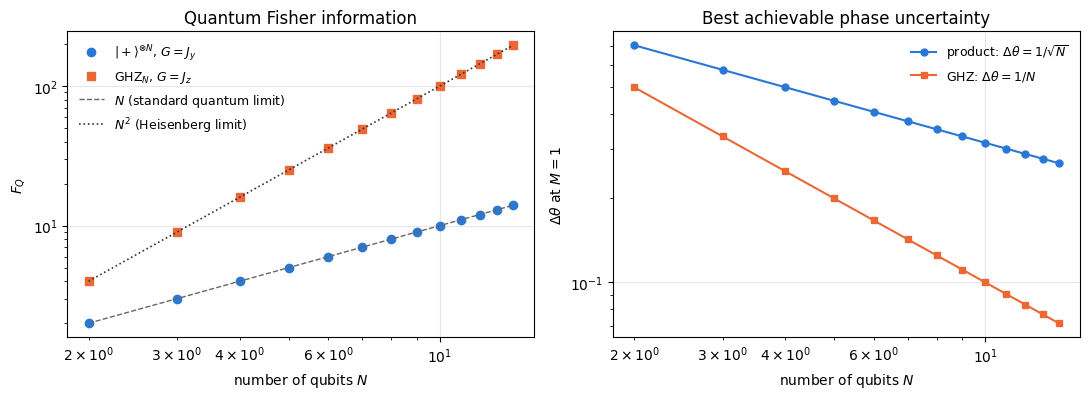

In [10]:
# ==============================================================================
# FIGURE: standard quantum limit vs Heisenberg limit
# ==============================================================================
Ns = np.array([r[0] for r in rows_scale], dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1))
axes[0].loglog(Ns, [r[1] for r in rows_scale], "o", color=PALETTE[0], ms=6, label=r"$\vert+\rangle^{\otimes N}$, $G=J_y$")
axes[0].loglog(Ns, [r[2] for r in rows_scale], "s", color=PALETTE[1], ms=6, label=r"GHZ$_N$, $G=J_z$")
axes[0].loglog(Ns, Ns, "--", color="0.4", lw=1, label=r"$N$ (standard quantum limit)")
axes[0].loglog(Ns, Ns ** 2, ":", color="0.2", lw=1.2, label=r"$N^2$ (Heisenberg limit)")
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel(r"$F_Q$")
axes[0].set_title("Quantum Fisher information"); axes[0].legend(fontsize=9)

axes[1].loglog(Ns, 1 / np.sqrt(np.array([r[1] for r in rows_scale])), "o-", color=PALETTE[0], ms=5,
               label=r"product: $\Delta\theta=1/\sqrt{N}$")
axes[1].loglog(Ns, 1 / np.sqrt(np.array([r[2] for r in rows_scale])), "s-", color=PALETTE[1], ms=5,
               label=r"GHZ: $\Delta\theta=1/N$")
axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel(r"$\Delta\theta$ at $M=1$")
axes[1].set_title("Best achievable phase uncertainty"); axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

The measured values are exactly $N$ and $N^2$ (the asserts demand agreement to $10^{-7}$), so both proofs of Section 9 are
confirmed and both bounds are tight. The right panel translates them into the quantity an experimentalist cares about:
with $N=14$ qubits the GHZ state promises a phase uncertainty $3.7$ times smaller than the best product state, and the
advantage grows as $\sqrt N$.

> **Physics insight.** The Heisenberg limit is not a licence to print precision. $F_Q=N^2$ is the *ideal* value; Sections 13
> and 14 show how quickly it collapses under noise and particle loss, and notebook 32 shows that even the ideal GHZ phase
> estimate suffers from an $N$-fold ambiguity, because its signal oscillates $N$ times faster.

## 10. A zoo of many-body states

Which states are metrologically useful? We evaluate $F_Q$ for the standard family of $N$-qubit states, each with the
generator that suits it, and compare against $N$ and $N^2$. Beyond the two extremes we already know, four entries deserve a
prediction before we look:

* **W state** $\vert W\rangle=\vert D_N^1\rangle$ (one excitation shared by all qubits). It is an eigenstate of $J_z$
  (eigenvalue $N/2-1$), so $F_Q=0$ for $G=J_z$ — a perfect illustration that the generator matters as much as the state.
  For $G=J_x$ we use the angular-momentum identity $\langle J_x^2\rangle=\tfrac12\left(\langle\mathbf J^2\rangle-\langle J_z^2\rangle\right)$
  valid in the symmetric sector (where $\langle J_x^2\rangle=\langle J_y^2\rangle$), with $j=N/2$, $m=N/2-1$:

  $$F_Q=4\cdot\tfrac12\left[\tfrac N2\left(\tfrac N2+1\right)-\left(\tfrac N2-1\right)^2\right]=3N-2 .$$

* **Dicke state at half filling** $\vert D_N^{N/2}\rangle$ ($m=0$, $N$ even). The same identity gives

  $$F_Q=4\cdot\tfrac12\cdot\tfrac N2\left(\tfrac N2+1\right)=\frac{N(N+2)}{2},$$

  i.e. Heisenberg *scaling* (asymptotically $N^2/2$) with a robustly preparable state. Dicke states are the workhorse of
  atomic metrology precisely because of this.
* **Cluster (graph) state.** Maximally entangled in the stabiliser sense, yet all its $\langle\sigma^a_q\rangle$ and most
  two-body correlators vanish — we will see what that does to $F_Q$.
* **Haar-random pure state.** For a random $\vert\psi\rangle$ the standard unitary-averaging identities
  $\mathbb{E}\langle A\rangle=\mathrm{Tr}A/d$ and $\mathbb{E}\langle A\rangle^2=\left[(\mathrm{Tr}A)^2+\mathrm{Tr}A^2\right]/[d(d+1)]$
  with $d=2^N$, $\mathrm{Tr}J_z=0$, $\mathrm{Tr}J_z^2=dN/4$ give the exact average

  $$\mathbb{E}\left[F_Q\right]=4\left(\frac N4-\frac{N}{4(d+1)}\right)=N\,\frac{d}{d+1}\;\xrightarrow[N\to\infty]{}\;N .$$

  A typical state of the Hilbert space is *entangled to the maximum* and yet worth exactly as much as a product state.

In [11]:
# ==============================================================================
# STEP 6: the zoo -- QFI of standard many-body states, and the Haar average
# ==============================================================================
N_ZOO = 8
N_HAAR_SAMPLES = 64

# Printed tables use ASCII names; figures use the LaTeX labels of LBL below.
LBL = {"|0>^N": r"$\vert 0\rangle^{\otimes N}$", "|+>^N": r"$\vert +\rangle^{\otimes N}$", "GHZ": "GHZ",
       "W": "W", "Dicke N/2": r"Dicke $N/2$", "cluster": "cluster", "Haar": "Haar random"}
zoo = {
    "|0>^N": (product_state("0" * N_ZOO), (0.0, 1.0, 0.0), "J_y"),
    "|+>^N": (product_state("+" * N_ZOO), (0.0, 1.0, 0.0), "J_y"),
    "GHZ": (ghz_state(N_ZOO), (0.0, 0.0, 1.0), "J_z"),
    "W": (w_state(N_ZOO), (1.0, 0.0, 0.0), "J_x"),
    "Dicke N/2": (dicke_state(N_ZOO, N_ZOO // 2), (1.0, 0.0, 0.0), "J_x"),
    "cluster": (cluster_state(N_ZOO), (0.0, 0.0, 1.0), "J_z"),
}
print(f"N = {N_ZOO}   (SQL: F_Q = {N_ZOO}, Heisenberg: F_Q = {N_ZOO ** 2})\n")
print(f"{'state':>12s} {'G':>5s} | {'F_Q':>10s} {'F_Q/N':>8s} {'F_Q/N^2':>9s} {'entangled?':>11s}")
for name, (psi, n, gname) in zoo.items():
    f = float(qfi_pure_direction(psi, n))
    print(f"{name:>12s} {gname:>5s} | {f:10.4f} {f / N_ZOO:8.3f} {f / N_ZOO ** 2:9.4f} "
          f"{'YES' if f > N_ZOO + 1e-6 else 'not by QFI':>11s}")

# Haar average: vmap over 64 independent random states (one PRNG key each)
keys = jax.random.split(jax.random.PRNGKey(0), N_HAAR_SAMPLES)
f_haar = jax.vmap(lambda k: qfi_pure_direction(haar_state(k, N_ZOO), (0.0, 0.0, 1.0)))(keys)
d, mean_haar, std_haar = 2 ** N_ZOO, float(jnp.mean(f_haar)), float(jnp.std(f_haar))
print(f"{'Haar (mean)':>12s} {'J_z':>5s} | {mean_haar:10.4f} {mean_haar / N_ZOO:8.3f} "
      f"{mean_haar / N_ZOO ** 2:9.4f} {'':>11s}")
sem_haar = std_haar / np.sqrt(N_HAAR_SAMPLES)
print(f"\nHaar average: measured {mean_haar:.4f} +- {sem_haar:.4f} (standard error of the mean "
      f"over {N_HAAR_SAMPLES} states, sample std {std_haar:.3f});  exact N d/(d+1) = {N_ZOO * d / (d + 1):.4f}")
# the measured mean must agree with the exact average within four standard errors
assert abs(mean_haar - N_ZOO * d / (d + 1)) < 4 * sem_haar

# --- CHECKPOINT: the analytic values predicted above ---------------------------------
assert abs(float(qfi_pure_direction(w_state(N_ZOO), (1.0, 0.0, 0.0))) - (3 * N_ZOO - 2)) < 1e3 * TOL
assert abs(float(qfi_pure_direction(dicke_state(N_ZOO, N_ZOO // 2), (1.0, 0.0, 0.0)))
           - N_ZOO * (N_ZOO + 2) / 2) < 1e3 * TOL
print("\nanalytic checks passed:  W -> 3N-2 = %d   Dicke(N/2) -> N(N+2)/2 = %d"
      % (3 * N_ZOO - 2, N_ZOO * (N_ZOO + 2) // 2))

N = 8   (SQL: F_Q = 8, Heisenberg: F_Q = 64)

       state     G |        F_Q    F_Q/N   F_Q/N^2  entangled?
       |0>^N   J_y |     8.0000    1.000    0.1250  not by QFI
       |+>^N   J_y |     8.0000    1.000    0.1250  not by QFI
         GHZ   J_z |    64.0000    8.000    1.0000         YES
           W   J_x |    22.0000    2.750    0.3437         YES
   Dicke N/2   J_x |    40.0000    5.000    0.6250         YES
     cluster   J_z |     8.0000    1.000    0.1250  not by QFI


 Haar (mean)   J_z |     7.9406    0.993    0.1241            

Haar average: measured 7.9406 +- 0.0835 (standard error of the mean over 64 states, sample std 0.668);  exact N d/(d+1) = 7.9689

analytic checks passed:  W -> 3N-2 = 22   Dicke(N/2) -> N(N+2)/2 = 40


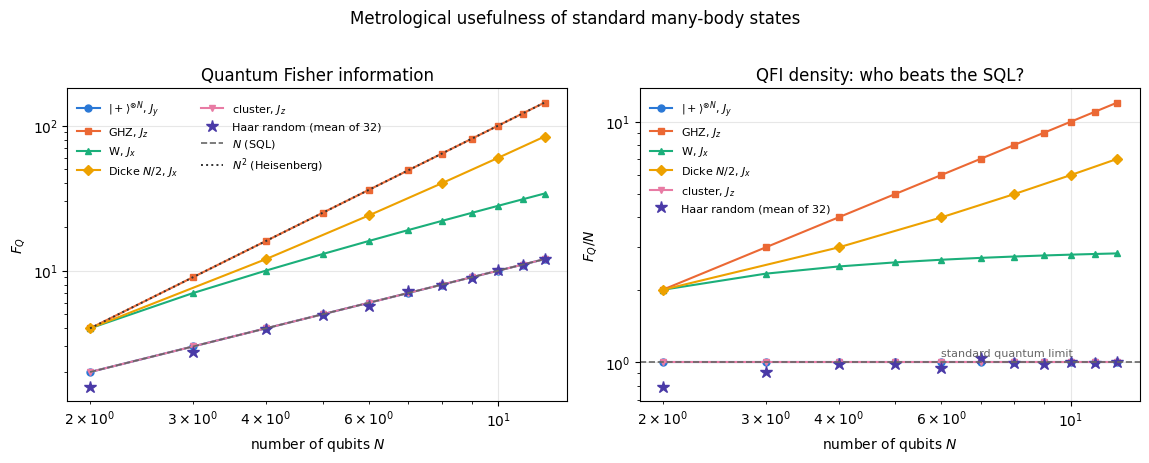

In [12]:
# ==============================================================================
# FIGURE: how the zoo scales with N
# ==============================================================================
N_RANGE = np.arange(2, 13)
curves = {
    r"$\vert+\rangle^{\otimes N}$, $J_y$": lambda N: qfi_pure_direction(product_state("+" * N), (0, 1, 0)),
    r"GHZ, $J_z$": lambda N: qfi_pure_direction(ghz_state(N), (0, 0, 1)),
    r"W, $J_x$": lambda N: qfi_pure_direction(w_state(N), (1, 0, 0)),
    r"Dicke $N/2$, $J_x$": lambda N: qfi_pure_direction(dicke_state(N, N // 2), (1, 0, 0)),
    r"cluster, $J_z$": lambda N: qfi_pure_direction(cluster_state(N), (0, 0, 1)),
}
haar_mean = np.array([float(jnp.mean(jax.vmap(lambda kk: qfi_pure_direction(haar_state(kk, N), (0, 0, 1)))(
    jax.random.split(jax.random.PRNGKey(N), 32)))) for N in N_RANGE])

fig, axes = plt.subplots(1, 2, figsize=(11.6, 4.5))
for k, (lab, fn) in enumerate(curves.items()):
    Nl = np.array([N for N in N_RANGE if (N % 2 == 0 or "Dicke" not in lab)])   # Dicke N/2 needs even N
    vals = np.array([float(fn(N)) for N in Nl])
    axes[0].loglog(Nl, vals, MARKERS[k] + "-", color=PALETTE[k], ms=5, label=lab)
    axes[1].semilogx(Nl, vals / Nl, MARKERS[k] + "-", color=PALETTE[k], ms=5, label=lab)
axes[0].loglog(N_RANGE, haar_mean, "*", color=PALETTE[5], ms=9, label="Haar random (mean of 32)")
axes[1].semilogx(N_RANGE, haar_mean / N_RANGE, "*", color=PALETTE[5], ms=9, label="Haar random (mean of 32)")
axes[0].loglog(N_RANGE, N_RANGE, "--", color="0.4", lw=1.2, label=r"$N$ (SQL)")
axes[0].loglog(N_RANGE, N_RANGE ** 2.0, ":", color="0.2", lw=1.4, label=r"$N^2$ (Heisenberg)")
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel(r"$F_Q$")
axes[0].set_title("Quantum Fisher information"); axes[0].legend(fontsize=8, ncol=2)
axes[1].axhline(1.0, color="0.4", ls="--", lw=1.2)
axes[1].text(6.0, 1.06, "standard quantum limit", fontsize=8, color="0.4")
axes[1].set_yscale("log"); axes[1].set_xlabel("number of qubits $N$"); axes[1].set_ylabel(r"$F_Q/N$")
axes[1].set_title("QFI density: who beats the SQL?"); axes[1].legend(fontsize=8)
fig.suptitle("Metrological usefulness of standard many-body states", y=1.02)
fig.tight_layout(); plt.show()

Read the figure from the bottom up.

* $\vert+\rangle^{\otimes N}$ with $G=J_y$ sits exactly on the SQL line: the best an unentangled state can do.
* The **cluster state** also sits exactly on $N$, even though it is a genuinely multipartite entangled stabiliser state —
  the standard resource for measurement-based quantum computation. Its collective fluctuations are precisely those of independent
  qubits, because all one-body expectation values and all same-Pauli two-body correlators vanish. **Entanglement is
  necessary but nowhere near sufficient for metrological gain.** (Section 11 will find a tilted direction where the
  cluster state does a little better than $N$ — the effect is a boundary artefact, not a scaling advantage.)
* The **Haar-random** points also collapse onto $N$, with a scatter that shrinks as $N$ grows; the measured mean at
  $N=8$, $7.94\pm0.08$ over $64$ states, is consistent with the exact prediction $N d/(d+1)=7.97$. A state drawn at
  random from the Hilbert space is maximally entangled and metrologically worthless — the useful states form a
  vanishingly small, highly structured subset.
* The **W state** at $3N-2$ beats the SQL by a constant factor but still scales linearly; its advantage disappears in
  relative terms as $N$ grows.
* The **Dicke state** at $N(N+2)/2$ and the **GHZ state** at $N^2$ are the two Heisenberg-scaling families, differing by
  a factor of about $2$.

> **Physics insight.** The QFI is a property of the *pair* (state, generator). The same W state is worth $3N-2$ with
> $G=J_x$ and exactly $0$ with $G=J_z$. Section 11 turns this observation into an algorithm for finding the best generator.

### 10.1 Ground states as a metrological resource

Many-body ground states are states a laboratory can reach by preparing the lowest-energy state of a tunable Hamiltonian
(for instance by an adiabatic ramp of a field) rather than by circuit engineering, which makes them attractive resources. Take the transverse-field Ising chain (our Pauli convention, see
[11 — Hamiltonians and ground states](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb)):

$$H(h)=-\sum_{q=0}^{N-2}Z_qZ_{q+1}-h\sum_{q=0}^{N-1}X_q .$$

For $h\ll1$ the ground state is the symmetric superposition of the two ferromagnetic configurations — a macroscopic
Schrödinger-cat state, essentially a GHZ state dressed by quantum fluctuations. For $h\gg1$ it is $\vert+\rangle^{\otimes N}$,
a product state. Somewhere in between (at $h=1$ in the limit $N\to\infty$) sits a quantum critical point. We compute
$F_Q$ for $G=J_z$ along the way with the Lanczos ground-state solver.

In [13]:
# ==============================================================================
# STEP 7: QFI of transverse-field Ising ground states across the transition
# ==============================================================================
H_FIELDS = (0.2, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0)
N_GS = (8, 10)
gs_rows = {}
t0 = time.time()
for N in N_GS:
    row = []
    for h in H_FIELDS:
        terms = heisenberg_terms(N, Jxx=0.0, Jyy=0.0, Jzz=-1.0, hx=-h)     # -ZZ bonds, -h X fields
        E, psi = lanczos_ground_state(terms, N, m=80, key=jax.random.PRNGKey(7), restarts=3)
        row.append((h, float(E), float(qfi_pure_direction(psi, (0, 0, 1))),
                    float(qfi_pure_direction(psi, (0, 1, 0)))))
    gs_rows[N] = row
print(f"(ground states computed in {time.time() - t0:.1f} s)\n")
for N in N_GS:
    print(f"N = {N}:")
    print(f"  {'h':>5s} {'E_0':>10s} | {'F_Q(J_z)':>10s} {'F_Q/N':>8s} {'F_Q/N^2':>9s} | {'F_Q(J_y)':>10s} {'F_Q/N':>8s}")
    for h, E, fz, fy in gs_rows[N]:
        print(f"  {h:5.2f} {E:10.4f} | {fz:10.4f} {fz / N:8.3f} {fz / N ** 2:9.4f} | {fy:10.4f} {fy / N:8.3f}")
    print()

(ground states computed in 27.2 s)

N = 8:
      h        E_0 |   F_Q(J_z)    F_Q/N   F_Q/N^2 |   F_Q(J_y)    F_Q/N
   0.20    -7.1003 |    63.0021    7.875    0.9844 |     7.8657    0.983
   0.50    -7.6406 |    56.8315    7.104    0.8880 |     6.7649    0.846
   0.80    -8.7492 |    39.9000    4.987    0.6234 |     3.5843    0.448
   1.00    -9.8380 |    28.1850    3.523    0.4404 |     2.5512    0.319
   1.20   -11.1082 |    21.4995    2.687    0.3359 |     2.6756    0.334
   1.50   -13.1914 |    16.6638    2.083    0.2604 |     3.3665    0.421
   2.00   -16.8851 |    13.3404    1.668    0.2084 |     4.3907    0.549
   3.00   -24.5863 |    11.0147    1.377    0.1721 |     5.5724    0.697

N = 10:
      h        E_0 |   F_Q(J_z)    F_Q/N   F_Q/N^2 |   F_Q(J_y)    F_Q/N
   0.20    -9.1204 |    98.5335    9.853    0.9853 |     9.8471    0.985
   0.50    -9.7655 |    89.6893    8.969    0.8969 |     8.8233    0.882
   0.80   -11.0675 |    63.3331    6.333    0.6333 |     5.0788    0.508

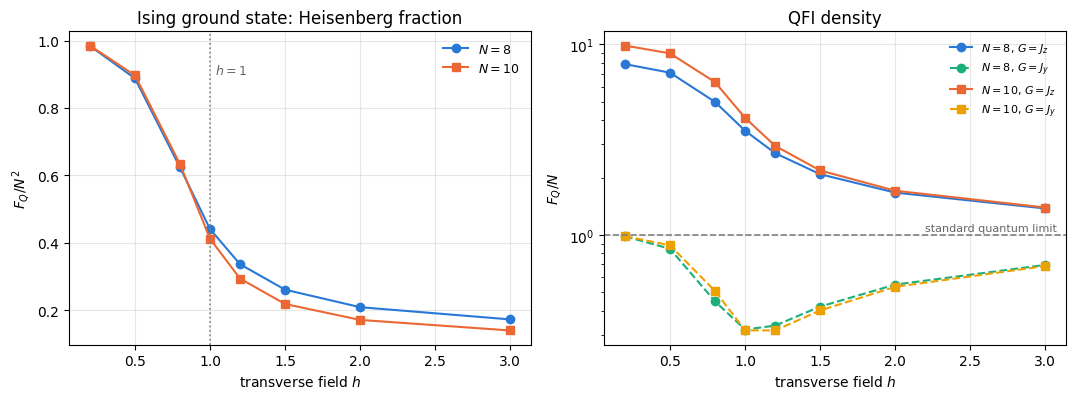

In [14]:
# ==============================================================================
# FIGURE: QFI density of the Ising ground state across the quantum phase transition
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1))
for k, N in enumerate(N_GS):
    hs = [r[0] for r in gs_rows[N]]
    axes[0].plot(hs, [r[2] / N ** 2 for r in gs_rows[N]], MARKERS[k] + "-", color=PALETTE[k], label=f"$N={N}$")
    axes[1].plot(hs, [r[2] / N for r in gs_rows[N]], MARKERS[k] + "-", color=PALETTE[k], label=f"$N={N}$, $G=J_z$")
    axes[1].plot(hs, [r[3] / N for r in gs_rows[N]], MARKERS[k] + "--", color=PALETTE[k + 2], label=f"$N={N}$, $G=J_y$")
axes[0].axvline(1.0, color="0.5", ls=":", lw=1.2)
axes[0].text(1.03, 0.9, "$h=1$", fontsize=9, color="0.4")
axes[0].set_xlabel("transverse field $h$"); axes[0].set_ylabel(r"$F_Q/N^2$")
axes[0].set_title("Ising ground state: Heisenberg fraction"); axes[0].legend(fontsize=9)
axes[1].axhline(1.0, color="0.5", ls="--", lw=1.2)
axes[1].text(2.2, 1.05, "standard quantum limit", fontsize=8, color="0.4")
axes[1].set_xlabel("transverse field $h$"); axes[1].set_ylabel(r"$F_Q/N$")
axes[1].set_yscale("log"); axes[1].set_title("QFI density"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

Deep in the ferromagnetic phase ($h=0.2$) the ground state reaches $F_Q/N^2\approx0.98$: the finite chain really is a
near-perfect GHZ state, and preparing the ground state of an Ising magnet is an alternative way to make one. As $h$ grows the cat is destroyed —
the ratio $F_Q/N^2$ falls monotonically through the transition region and, by $h=3$, $F_Q$ has dropped to a little above
the SQL value $N$. $F_Q/N$ for $G=J_z$ stays above $1$ everywhere we look: the Ising ground state is entangled at every
finite field, and the QFI witnesses it.

The perpendicular generator $J_y$ tells a different and initially surprising story: its QFI density is *not* monotonic.
It starts at $F_Q(J_y)/N\approx0.98$ at $h=0.2$, falls to a minimum of $\approx0.32$ at $h=1$, and climbs back to
$\approx0.7$ at $h=3$. Both ends are easy: at $h\to0$ the state is the cat $(\vert0\cdots0\rangle+\vert1\cdots1\rangle)/\sqrt2$,
for which $\mathrm{Var}(J_y)=N/4$ exactly, the same as for a product state; at $h\to\infty$ the state is
$\vert+\rangle^{\otimes N}$, for which $\mathrm{Var}(J_y)=N/4$ as well. In between, the transverse fluctuations are
reduced by the interaction. Since $\langle Y_q\rangle=0$ by symmetry, Eq. (14) reads
$F_Q(J_y)=N+\sum_{q\neq q'}\langle Y_qY_{q'}\rangle$, so a density below $1$ means a net *negative* $y$-$y$ correlation;
it is largest in magnitude in the critical region near $h=1$, where the correlation length is longest. Reading the two generators together: the transition transfers
metrological weight from $J_y$ into $J_z$ as $h$ decreases, and the critical region is where the transfer happens.

> **Numerical practice.** In the ordered phase the finite chain has two almost degenerate lowest states of opposite
> $\prod_q X_q$ parity — the symmetric and the antisymmetric cat — split by about $5\times10^{-6}$ at $N=8$, $h=0.2$.
> Which of the two a solver returns does not matter here: both are parity eigenstates and both give the same
> $F_Q\approx0.98N^2$. What *would* matter is landing on a symmetry-broken superposition
> $\alpha\vert\!\uparrow\cdots\uparrow\rangle+\beta\vert\!\downarrow\cdots\downarrow\rangle$: then
> $F_Q\approx N^2\left(1-(\vert\alpha\vert^2-\vert\beta\vert^2)^2\right)$, anywhere between $N^2$ and $0$, and for the
> fully polarised choice it collapses to a number of order $1$. Lanczos with a fixed seed and several restarts stayed on
> a parity eigenstate here — the printed energies and the QFI are smooth in $h$ — but with a poorer solver one can easily
> land anywhere in that family. Always check that a computed quantity is smooth in the parameter before interpreting it.

## 11. The $3\times3$ QFI matrix and the optimal generator direction

So far we chose the generator direction $\mathbf n$ by hand. We can do better: for collective generators the dependence on
$\mathbf n$ is *quadratic*, so the optimisation over the whole sphere reduces to a $3\times3$ eigenvalue problem.

### 11.1 Derivation

Let $G=\mathbf n\cdot\mathbf J=\sum_a n_aJ_a$ with $\mathbf n$ a real unit vector. Then

$$\mathrm{Var}(G)=\langle G^2\rangle-\langle G\rangle^2
=\sum_{a,b}n_an_b\left[\tfrac12\langle J_aJ_b+J_bJ_a\rangle-\langle J_a\rangle\langle J_b\rangle\right],$$

where the symmetrisation is free: $n_an_b$ is symmetric under $a\leftrightarrow b$, so only the symmetric part of
$\langle J_aJ_b\rangle$ survives the double sum. Defining the real symmetric **covariance matrix**

$$C_{ab}=\tfrac12\langle J_aJ_b+J_bJ_a\rangle-\langle J_a\rangle\langle J_b\rangle \tag{16}$$

and the **QFI matrix**

$$\mathcal{F}_{ab}=4\,C_{ab}, \tag{17}$$

we get the compact statement

$$F_Q(\mathbf n)=\mathbf n^{\mathsf T}\,\mathcal{F}\,\mathbf n . \tag{18}$$

Maximising a quadratic form over unit vectors is the Rayleigh-quotient problem: since $\mathcal F$ is real symmetric it has
an orthonormal eigenbasis $\mathcal F\mathbf v_k=\lambda_k\mathbf v_k$ with $\lambda_1\le\lambda_2\le\lambda_3$; expanding
$\mathbf n=\sum_k c_k\mathbf v_k$ with $\sum_kc_k^2=1$ gives $\mathbf n^{\mathsf T}\mathcal F\mathbf n=\sum_k\lambda_kc_k^2\le\lambda_3$,
with equality for $\mathbf n=\mathbf v_3$. Hence

$$\max_{\mathbf n}F_Q(\mathbf n)=\lambda_{\max}(\mathcal F),\qquad
  \mathbf n_{\text{opt}}=\text{eigenvector of }\mathcal F\text{ for }\lambda_{\max} . \tag{19}$$

Three matrix elements per pair of axes, one $3\times3$ `eigh`, and the optimisation over the sphere is done exactly.

The identification $\mathcal F=4C$ of Eq. (17) uses $F_Q=4\,\mathrm{Var}(G)$ and is therefore valid **only for pure
states**. The eigenvalue argument itself survives for mixed states, because the mixed-state formula of Eq. (22) below is
also quadratic in the generator: $F_Q(\mathbf n)=\mathbf n^{\mathsf T}\Gamma\mathbf n$ with

$$\Gamma_{ab}=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}\,
  \mathrm{Re}\!\left[\langle m\vert J_a\vert n\rangle\langle n\vert J_b\vert m\rangle\right].$$

For a mixed state $\Gamma$ is in general *smaller* than $4C$, so feeding a covariance matrix into Eq. (19) returns an
upper bound on the optimal QFI rather than the optimal QFI. Notebook 30 makes that gap explicit. Everything in this
section is applied to pure states only, where the two coincide.

### 11.2 Code

The engine's `spin_moments` returns exactly $\langle\mathbf J\rangle$ and the symmetrised covariance $C$ of Eq. (16),
computed matrix-free: it forms $\vert\phi_a\rangle=J_a\vert\psi\rangle$ for $a=x,y,z$ (three calls of `apply_collective`) and
reads off $\tfrac12\langle J_aJ_b+J_bJ_a\rangle=\mathrm{Re}\,\langle\phi_a\vert\phi_b\rangle$ — the real part of an inner
product *is* the symmetrised moment, because $\langle\phi_a\vert\phi_b\rangle=\langle J_aJ_b\rangle$ and
$\langle J_bJ_a\rangle=\overline{\langle J_aJ_b\rangle}$.

In [15]:
# ==============================================================================
# STEP 8: the 3x3 QFI matrix and the optimal generator direction
# ==============================================================================
def qfi_matrix(psi):
    """3x3 QFI matrix of a pure state over the collective generators (J_x, J_y, J_z).

    MATH   Fcal[a,b] = 4 * ( (1/2)<J_a J_b + J_b J_a> - <J_a><J_b> ),   F_Q(n) = n^T Fcal n   (Eq. 18)
    COST   three matrix-free applications of J_a: O(N 2^N).
    """
    _, cov = spin_moments(psi)
    return 4.0 * cov


def optimal_direction(psi):
    """Best generator direction and the QFI it delivers: (F_max, n_opt) from Eq. (19)."""
    F = qfi_matrix(psi)
    w, v = jnp.linalg.eigh(F)                 # eigenvalues ascending
    return w[-1], v[:, -1]


# --- CHECKPOINT: the quadratic form, Eq. (18), reproduces the direct matrix-free QFI ------------
N_DIR = 6
states_dir = {"GHZ": ghz_state(N_DIR), "W": w_state(N_DIR), "Dicke N/2": dicke_state(N_DIR, N_DIR // 2),
              "|+>^N": product_state("+" * N_DIR), "cluster": cluster_state(N_DIR),
              "Haar": haar_state(jax.random.PRNGKey(3), N_DIR)}
key_dirs = jax.random.normal(jax.random.PRNGKey(11), (12, 3))
key_dirs = key_dirs / jnp.linalg.norm(key_dirs, axis=1, keepdims=True)     # 12 random unit directions
err_quad = 0.0
for name, psi in states_dir.items():
    F = qfi_matrix(psi)
    for n in key_dirs:
        err_quad = max(err_quad, abs(float(n @ F @ n) - float(qfi_pure_direction(psi, n))))
print(f"max |n^T Fcal n  -  4 Var(n.J)| over 6 states x 12 random directions = {err_quad:.2e}")
assert err_quad < 1e4 * TOL

print(f"\nN = {N_DIR}   (SQL: {N_DIR},  Heisenberg: {N_DIR ** 2})\n")
print(f"{'state':>12s} | {'eigenvalues of Fcal':>32s} | {'F_max':>9s} {'n_opt':>24s} {'F(J_z)':>9s}")
for name, psi in states_dir.items():
    F = qfi_matrix(psi)
    w = np.array(jnp.linalg.eigvalsh(F))
    fmax, nopt = optimal_direction(psi)
    nopt = np.array(nopt) * np.sign(np.array(nopt)[np.argmax(np.abs(np.array(nopt)))])   # fix the global sign
    print(f"{name:>12s} | {np.array2string(w, precision=3, floatmode='fixed'):>32s} | {float(fmax):9.4f} "
          f"{np.array2string(nopt, precision=3, floatmode='fixed'):>24s} {float(qfi_pure_direction(psi, (0, 0, 1))):9.4f}")

max |n^T Fcal n  -  4 Var(n.J)| over 6 states x 12 random directions = 2.58e-14

N = 6   (SQL: 6,  Heisenberg: 36)

       state |              eigenvalues of Fcal |     F_max                    n_opt    F(J_z)


         GHZ |           [ 6.000  6.000 36.000] |   36.0000      [0.000 0.000 1.000]   36.0000
           W | [-3.553e-15  1.600e+01  1.600e+01] |   16.0000      [1.000 0.000 0.000]   -0.0000
   Dicke N/2 |  [6.163e-33 2.400e+01 2.400e+01] |   24.0000      [1.000 0.000 0.000]    0.0000
       |+>^N |  [1.421e-14 6.000e+00 6.000e+00] |    6.0000   [-0.000  1.000 -0.000]    6.0000
     cluster |              [4.000 6.000 8.000] |    8.0000   [ 0.707 -0.000  0.707]    6.0000
        Haar |              [4.078 6.291 7.073] |    7.0734   [ 0.714 -0.652  0.253]    4.9909


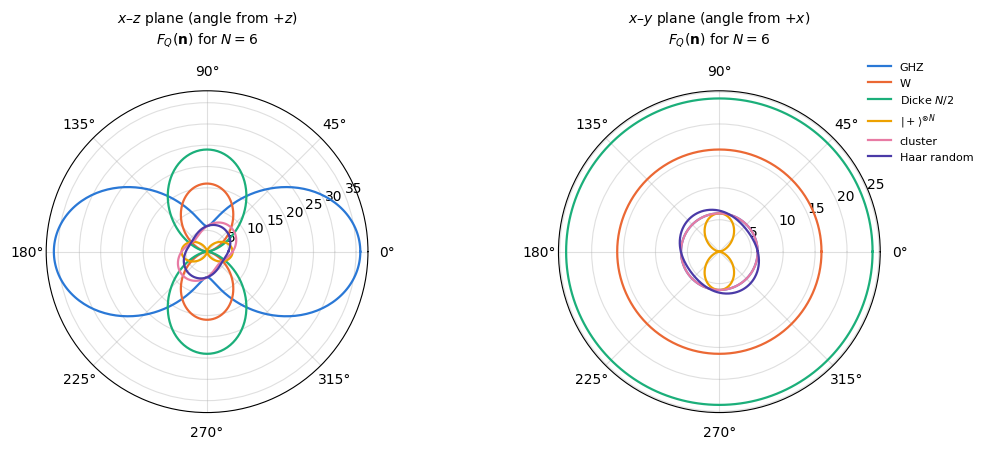

In [16]:
# ==============================================================================
# FIGURE: F_Q as a function of the generator direction, in two great circles
# ==============================================================================
angles = np.linspace(0, 2 * np.pi, 361)
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.6), subplot_kw={"projection": "polar"})
for k, (name, psi) in enumerate(list(states_dir.items())):
    F = np.array(qfi_matrix(psi))
    xz = np.array([[np.sin(a), 0.0, np.cos(a)] for a in angles])          # great circle in the x-z plane
    xy = np.array([[np.cos(a), np.sin(a), 0.0] for a in angles])          # great circle in the x-y plane
    axes[0].plot(angles, np.einsum("ia,ab,ib->i", xz, F, xz), color=PALETTE[k % 6], lw=1.6, label=LBL[name])
    axes[1].plot(angles, np.einsum("ia,ab,ib->i", xy, F, xy), color=PALETTE[k % 6], lw=1.6, label=LBL[name])
for ax, ttl in zip(axes, [r"$x$–$z$ plane (angle from $+z$)", r"$x$–$y$ plane (angle from $+x$)"]):
    ax.set_title(ttl + f"\n$F_Q(\\mathbf{{n}})$ for $N={N_DIR}$", fontsize=10, pad=16)
    ax.grid(alpha=0.4)
axes[1].legend(fontsize=8, loc="upper right", bbox_to_anchor=(1.32, 1.12))
fig.tight_layout(); plt.show()

The polar plots are the quadratic form of Eq. (18) drawn as a radius: an ellipse-like curve (strictly, the restriction of a
quadric to a great circle) whose longest axis is the optimal direction.

* **GHZ** is a two-lobed figure along $\hat z$ with $F_Q=N^2=36$ there and only $F_Q=N=6$ in the perpendicular plane.
  Point the generator the wrong way and a Heisenberg-limited state degrades to the standard quantum limit.
* **W** and **Dicke** are the opposite: flat and *isotropic* in the $x$–$y$ plane (they are $J_z$ eigenstates, so the
  $z$ direction carries nothing) — any equatorial direction is optimal.
* $\vert+\rangle^{\otimes N}$ is a circle of radius $N$ in the $y$–$z$ plane and vanishes along $\hat x$, its own polarisation axis.
* The **cluster state** is the interesting one. Its three eigenvalues at $N=6$ come out as $(4,6,8)$: unlike the naive
  $F_Q=N$ along every Cartesian axis, the optimal direction is the diagonal $(\mathbf{\hat x}+\mathbf{\hat z})/\sqrt2$ and
  gives $F_Q=8>N=6$. The off-diagonal entry comes from the two *boundary* stabilisers of the open chain, $K_0=X_0Z_1$ and
  $K_{N-1}=Z_{N-2}X_{N-1}$. Since every $\langle J_a\rangle$ vanishes and $\sigma^x_q$ anticommutes with $\sigma^z_q$ on the
  same site, only $q\neq q'$ survives in Eq. (16) and $\mathcal{F}_{xz}=\sum_{q\neq q'}\langle X_qZ_{q'}\rangle
  =\langle X_0Z_1\rangle+\langle X_{N-1}Z_{N-2}\rangle=1+1=2$, while the diagonal stays at $N$; the eigenvalues are then
  $N-2,\,N,\,N+2$, exactly the $(4,6,8)$ printed above. So the cluster state *is* detected as entangled — but only if you
  look along the right axis, and the excess is a boundary effect of order $1$ (we measure $F_{\max}=N+2$ at both $N=6$
  and $N=8$), not a change of scaling.
* The **Haar-random** state is a generic, mildly anisotropic blob with all three eigenvalues near $N$.

> **Numerical practice.** Replacing an optimisation over a continuum (here: the unit sphere of directions) by an exact
> eigenvalue problem is always worth hunting for. It costs one `eigh` of a $3\times3$ matrix instead of a gradient descent
> that can stall in local maxima, and it returns the *global* optimum with a certificate. Notebook 34 uses exactly this
> $3\times3$ matrix to track the optimal measurement axis along a one-axis-twisting evolution.

## 12. The QFI as an entanglement witness

Section 9 proved $F_Q\le N$ for separable states. Turned around, this is one of the most useful entanglement criteria in
experimental many-body physics, because it is *operational*: it does not just say "entangled", it says "entangled enough to
beat the shot-noise limit in an interferometer".

**Criterion 1 (Pezzè and Smerzi 2009).** For every separable state of $N$ qubits and every collective generator
$G=\mathbf n\cdot\mathbf J$,

$$F_Q[\rho,G]\le N;\qquad\text{therefore}\quad F_Q>N\;\Longrightarrow\;\rho\text{ is entangled.} \tag{20}$$

**Criterion 2 (Hyllus et al. 2012; Tóth 2012).** Call a state **$k$-producible** if it is a mixture of products of blocks of
at most $k$ qubits (so $k=1$ means separable). Writing $N=sk+r$ with $s=\lfloor N/k\rfloor$ and $0\le r<k$, every
$k$-producible state obeys

$$F_Q[\rho,G]\;\le\;s\,k^2+r^2\;\le\;kN . \tag{21}$$

(The second inequality holds because $kN=sk^2+kr$ and $r<k$.) Consequently $F_Q>s\,k^2+r^2$ certifies **entanglement
depth** at least $k+1$: some block of at least $k+1$ qubits is genuinely entangled. We always use the *sharp* middle
expression, never the weaker $kN$ — for $N=8$, $k=3$ the two differ by $2$, and that difference decides the verdict for
the W state below. Both criteria are quoted here; their proofs use the convexity of the QFI plus the single-block bound
$F_Q\le k^2$, which is the Heisenberg-limit argument of Section 9.2 applied to a block of $k$ qubits.

Let us apply the criteria to the zoo.

In [17]:
# ==============================================================================
# STEP 9: entanglement depth certified by the QFI, Eq. (21)
# ==============================================================================
def entanglement_depth(F_value, N):
    """Largest k+1 such that F_Q > s k^2 + r^2 with s = N//k, r = N%k  --  the certified entanglement depth.

    Returns 1 if the QFI certifies nothing (F_Q <= N), otherwise the smallest block size that must be
    genuinely entangled.  MATH: Eq. (21), k-producible states obey F_Q <= s k^2 + r^2.
    """
    depth = 1
    for k in range(1, N + 1):
        s, r = divmod(N, k)
        if F_value > s * k ** 2 + r ** 2 + 1e-9:     # k-producible is EXCLUDED
            depth = k + 1
    return depth


N_W = 8
print(f"N = {N_W}:  bound of Eq. (21) for k-producible states")
print("   " + "  ".join(f"k={k}: {N_W // k * k ** 2 + (N_W % k) ** 2:3d}" for k in range(1, N_W + 1)))
print(f"\n{'state':>20s} {'G':>7s} | {'F_Q':>9s} {'F_Q/N':>7s} | {'entangled':>10s} {'depth >=':>9s} {'S(N/2 cut)':>11s}")
wit_states = [
    ("|+>^N", product_state("+" * N_W), (0, 1, 0), "J_y"),
    ("W", w_state(N_W), (1, 0, 0), "J_x"),
    ("cluster (opt.dir.)", cluster_state(N_W), None, "n_opt"),
    ("Dicke N/2", dicke_state(N_W, N_W // 2), (1, 0, 0), "J_x"),
    ("GHZ", ghz_state(N_W), (0, 0, 1), "J_z"),
    ("Haar random", haar_state(jax.random.PRNGKey(5), N_W), None, "n_opt"),
]
for name, psi, n, gname in wit_states:
    f = float(optimal_direction(psi)[0]) if n is None else float(qfi_pure_direction(psi, n))
    S = float(entanglement_entropy(psi, range(N_W // 2)))
    print(f"{name:>20s} {gname:>7s} | {f:9.4f} {f / N_W:7.3f} | {'YES' if f > N_W else 'no':>10s} "
          f"{entanglement_depth(f, N_W):9d} {S:11.3f}")

N = 8:  bound of Eq. (21) for k-producible states
   k=1:   8  k=2:  16  k=3:  22  k=4:  32  k=5:  34  k=6:  40  k=7:  50  k=8:  64

               state       G |       F_Q   F_Q/N |  entangled  depth >=  S(N/2 cut)


               |+>^N     J_y |    8.0000   1.000 |         no         1       0.000
                   W     J_x |   22.0000   2.750 |        YES         3       1.000
  cluster (opt.dir.)   n_opt |   10.0000   1.250 |        YES         2       1.000
           Dicke N/2     J_x |   40.0000   5.000 |        YES         6       1.642
                 GHZ     J_z |   64.0000   8.000 |        YES         8       1.000
         Haar random   n_opt |    8.2048   1.026 |        YES         2       3.212


The table puts the two halves of the story side by side. The last column is the entanglement entropy across the middle cut —
the standard *quantitative* entanglement measure for pure states — and it is uncorrelated with metrological
usefulness. The Haar-random state has by far the largest entropy ($3.21$ bits out of a maximum of $4$, close to the Page
value) and yet, even in its optimal direction, it reaches only $F_Q=8.20$ against the separable bound $N=8$: the QFI
certifies a depth of merely $2$, i.e. essentially nothing. The cluster state stops at depth $2$ as well, although it is
a genuinely $8$-partite entangled stabiliser state. The GHZ state has just **one** bit of entropy across the cut — the
same as the cluster state — and is certified as genuinely $8$-partite entangled; the Dicke state, with $1.64$ bits,
reaches depth $6$.

The W state is worth a second look because it lands exactly on a bound: $F_Q=22$ and the $k=3$ bound of Eq. (21) is
$s k^2+r^2=2\cdot 9+2^2=22$. The inequality in Eq. (21) is not strict, so a value *equal* to the bound excludes nothing:
$3$-producibility survives and the certified depth is $3$, not $4$. (That $\vert W_8\rangle$ is in fact genuinely
$8$-partite entangled is true but invisible to this witness — a reminder that Eq. (21) is a one-sided criterion, and that
the exact-equality case has to be decided by the inequality as written, not by a floating-point comparison. The
`+1e-9` in `entanglement_depth` is what implements "not strictly greater".)

> **Physics insight.** "How much entanglement" and "how useful the entanglement is" are different questions with different
> answers. Metrology cares about *collective, coherent* superpositions of macroscopically distinct configurations, not
> about the volume of the entangled Hilbert space. This is why the phrase "useful entanglement" appears so often in the
> metrology literature, and why $F_Q$ rather than an entropy is the figure of merit.

## 13. Noise: QFI of mixed states

Real devices produce mixed states, and Eq. (14) no longer applies — a mixed state has no single $\vert\psi\rangle$ whose
variance we could take. The general answer is the symmetric-logarithmic-derivative formula. Written in the eigenbasis
$\rho=\sum_m\lambda_m\vert m\rangle\langle m\vert$, for unitary encoding with generator $G$, it reads

$$F_Q[\rho,G]\;=\;2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{(\lambda_m-\lambda_n)^2}{\lambda_m+\lambda_n}
  \left\vert\langle m\vert G\vert n\rangle\right\vert^2 . \tag{22}$$

This is what the engine's `qfi_mixed` implements, and it is the *only* place in this notebook where we use a result without
proving it: the full derivation — the Lyapunov equation for the SLD, its solution in the eigenbasis, the treatment of the
kernel, the reduction of Eq. (22) to $4\mathrm{Var}(G)$ for pure states, and the explicit optimal measurement — is the
subject of the next notebook,
[30 — QFI from the SLD](../ch10_quantum_metrology_protocols/30_qfi_from_the_sld_prepare_encode_estimate.ipynb).
Two features of Eq. (22) matter here: it costs a full eigendecomposition, $O(8^N)$, so it is a
small-system tool ($N\le7$ in practice); and every term is non-negative, so mixing can only be understood by looking at
how *both* the eigenvalues and the matrix elements change.

One inequality is worth recording now, because it will be used repeatedly later in the chapter. Since
$(\lambda_m-\lambda_n)^2\le(\lambda_m+\lambda_n)^2$ for non-negative eigenvalues, Eq. (22) is bounded by
$2\sum_{m,n}(\lambda_m+\lambda_n)\left\vert\langle m\vert G\vert n\rangle\right\vert^2=4\langle G^2\rangle$, and a slightly
more careful version of the same argument gives

$$F_Q[\rho,G]\;\le\;4\,\mathrm{Var}_\rho(G),$$

with equality if and only if $\rho$ is pure. So $4\,\mathrm{Var}(G)$ never *under*-estimates the quantum Fisher
information — it is the right answer for pure states and an upper bound for mixed ones. Notebook 30 proves the
inequality and notebook 36 measures how large the gap becomes for noisy states.

### 13.1 An analytic test case: dephased GHZ

Apply single-qubit dephasing (probability $p$ of a $Z$ error) to each of the $N$ qubits of a GHZ state. Dephasing leaves
the populations alone and multiplies each coherence $\rho_{ss'}$ by $(1-2p)$ for every qubit at which $s$ and $s'$ differ.
The GHZ state has exactly one coherence, between $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$, and those two strings
differ at **all** $N$ qubits, so

$$\rho(p)=\frac12\Big(\vert0\cdots0\rangle\langle0\cdots0\vert+\vert1\cdots1\rangle\langle1\cdots1\vert\Big)
  +c\Big(\vert0\cdots0\rangle\langle1\cdots1\vert+\text{h.c.}\Big),\qquad c=\tfrac12(1-2p)^N .$$

Everything lives in the two-dimensional space spanned by $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$, where
$\rho=\begin{pmatrix}1/2&c\\c&1/2\end{pmatrix}$ has eigenvalues $\lambda_\pm=\tfrac12\pm c$ with eigenvectors
$(\vert0\cdots0\rangle\pm\vert1\cdots1\rangle)/\sqrt2$, and $J_z=\tfrac N2\,\mathrm{diag}(1,-1)$ becomes purely
off-diagonal, $\langle+\vert J_z\vert-\rangle=N/2$. Equation (22) then has just the two terms $(m,n)=(+,-)$ and $(-,+)$:

$$F_Q=2\cdot2\cdot\frac{(2c)^2}{1}\cdot\frac{N^2}{4}=4c^2N^2=N^2(1-2p)^{2N} . \tag{23}$$

The Heisenberg value $N^2$ is multiplied by $(1-2p)^{2N}$: the advantage dies **exponentially in $N$** at fixed error
probability. Equation (23) is the quantitative statement of GHZ fragility. We check it, and then compare the three
standard channels.

In [18]:
# ==============================================================================
# STEP 10: QFI of noisy states -- density tensors and the mixed-state formula
# ==============================================================================
# PARAMETERS ------------------------------------------------------------------
N_NOISE = 6                                   # density tensor of 2^6 x 2^6 = 64 x 64 -- comfortable
P_GRID = np.array([0.0, 0.005, 0.01, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30])
# -----------------------------------------------------------------------------
CHANNELS = {"depolarising": kraus_depolarizing, "dephasing": kraus_dephasing,
            "amplitude damping": kraus_amplitude_damping}


def apply_local_channel(rho, kraus_fn, p, qubits=None):
    """Apply the SAME single-qubit channel to each listed qubit of a density TENSOR.

    MATH   rho -> (E_p (x) E_p (x) ... ) rho,  each E_p(sigma) = sum_m K_m sigma K_m^dagger.
    COST   O(N 4^N) -- one `apply_kraus_dm` einsum per qubit; the 4^N x 4^N superoperator never exists.
    """
    N = rho.ndim // 2
    qubits = range(N) if qubits is None else qubits
    K = kraus_fn(p)
    for q in qubits:
        rho = apply_kraus_dm(rho, K, [q])
    return rho


def qfi_noisy(rho_tensor, n, N):
    """QFI of a mixed state for the generator n.J, via the engine's mixed-state (SLD) formula, Eq. (22)."""
    return qfi_mixed(dm_matrix(rho_tensor), collective_dense(pauli_direction(n), N))


# --- CHECKPOINT: the analytic dephasing formula, Eq. (23) -----------------------------
print("dephased GHZ: numerical Eq. (22) vs analytic Eq. (23)   F_Q = N^2 (1-2p)^{2N}\n")
print(f"{'N':>3s} {'p':>6s} | {'F_Q (numeric)':>14s} {'F_Q (analytic)':>15s} {'rel. err':>10s}")
for N in (3, 5, 6):
    for p in (0.02, 0.10, 0.25):
        rho = apply_local_channel(to_dm(ghz_state(N)), kraus_dephasing, p)
        f_num = float(qfi_noisy(rho, (0, 0, 1), N))
        f_ana = N ** 2 * (1 - 2 * p) ** (2 * N)
        print(f"{N:3d} {p:6.2f} | {f_num:14.8f} {f_ana:15.8f} {abs(f_num - f_ana) / f_ana:10.2e}")
        assert abs(f_num - f_ana) < 1e4 * TOL

dephased GHZ: numerical Eq. (22) vs analytic Eq. (23)   F_Q = N^2 (1-2p)^{2N}

  N      p |  F_Q (numeric)  F_Q (analytic)   rel. err


  3   0.02 |     7.04482011      7.04482011   2.52e-16
  3   0.10 |     2.35929600      2.35929600   1.32e-15
  3   0.25 |     0.14062500      0.14062500   2.37e-15


  5   0.02 |    16.62081590     16.62081590   6.41e-16
  5   0.10 |     2.68435456      2.68435456   1.49e-15
  5   0.25 |     0.02441406      0.02441406   2.98e-15


  6   0.02 |    22.05755126     22.05755126   1.13e-15
  6   0.10 |     2.47390116      2.47390116   2.15e-15


  6   0.25 |     0.00878906      0.00878906   7.70e-15


In [19]:
# ==============================================================================
# STEP 11: three channels, GHZ vs product state, N = 2 ... 6
# ==============================================================================
noise_data = {}
t0 = time.time()
for cname, kfn in CHANNELS.items():
    for N in (2, 3, 4, 5, 6):
        vals = []
        for p in P_GRID:
            rho = apply_local_channel(to_dm(ghz_state(N)), kfn, float(p))
            vals.append(float(qfi_noisy(rho, (0, 0, 1), N)))
        noise_data[(cname, N)] = np.array(vals)
print(f"(noise sweep computed in {time.time() - t0:.1f} s)\n")

print(f"GHZ_N, generator J_z, QFI normalised by the ideal value N^2\n")
for cname in CHANNELS:
    print(f"  {cname}:")
    print("    " + f"{'N':>3s} | " + " ".join(f"p={p:<5.3f}" for p in P_GRID))
    for N in (2, 4, 6):
        v = noise_data[(cname, N)] / N ** 2
        print("    " + f"{N:3d} | " + " ".join(f"{x:7.4f}" for x in v))
    print()

(noise sweep computed in 14.3 s)

GHZ_N, generator J_z, QFI normalised by the ideal value N^2

  depolarising:
      N | p=0.000 p=0.005 p=0.010 p=0.020 p=0.050 p=0.100 p=0.150 p=0.200 p=0.300
      2 |  1.0000  0.9801  0.9604  0.9218  0.8111  0.6444  0.4995  0.3761  0.1906
      4 |  1.0000  0.9606  0.9225  0.8500  0.6595  0.4194  0.2557  0.1482  0.0408
      6 |  1.0000  0.9415  0.8861  0.7836  0.5355  0.2716  0.1293  0.0571  0.0083

  dephasing:
      N | p=0.000 p=0.005 p=0.010 p=0.020 p=0.050 p=0.100 p=0.150 p=0.200 p=0.300
      2 |  1.0000  0.9606  0.9224  0.8493  0.6561  0.4096  0.2401  0.1296  0.0256
      4 |  1.0000  0.9227  0.8508  0.7214  0.4305  0.1678  0.0576  0.0168  0.0007
      6 |  1.0000  0.8864  0.7847  0.6127  0.2824  0.0687  0.0138  0.0022  0.0000

  amplitude damping:
      N | p=0.000 p=0.005 p=0.010 p=0.020 p=0.050 p=0.100 p=0.150 p=0.200 p=0.300
      2 |  1.0000  0.9950  0.9899  0.9796  0.9475  0.8901  0.8281  0.7619  0.6203
      4 |  1.0000  0.9900  0.9799

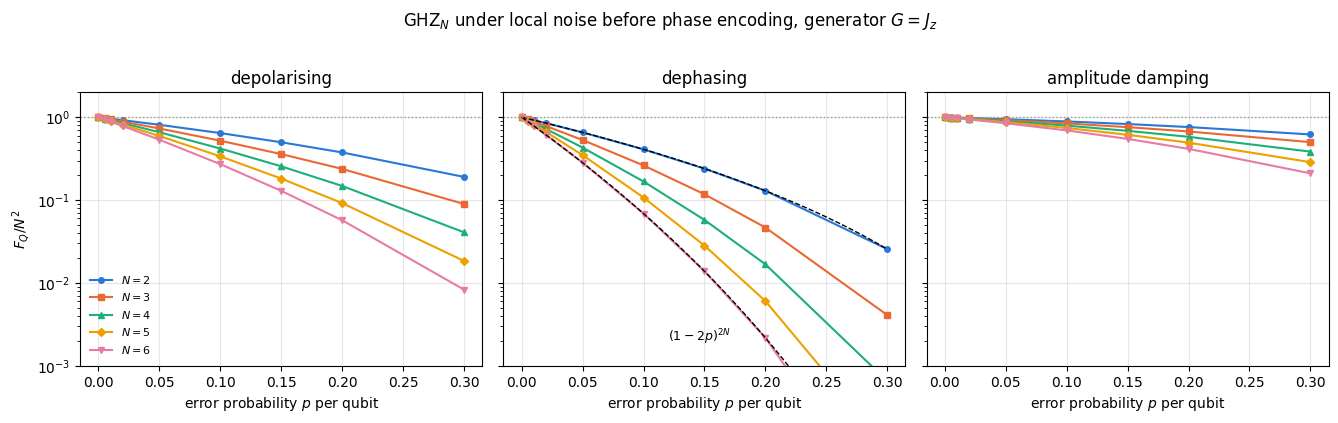

In [20]:
# ==============================================================================
# FIGURE: fragility of the Heisenberg limit
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.1), sharey=True)
for j, cname in enumerate(CHANNELS):
    for k, N in enumerate((2, 3, 4, 5, 6)):
        axes[j].semilogy(P_GRID, noise_data[(cname, N)] / N ** 2, MARKERS[k] + "-",
                         color=PALETTE[k], ms=4, label=f"$N={N}$")
    if cname == "dephasing":
        pp = np.linspace(0, 0.3, 200)
        for k, N in enumerate((2, 6)):
            axes[j].semilogy(pp, (1 - 2 * pp) ** (2 * N), "k--", lw=1)
        axes[j].text(0.12, 2e-3, r"$(1-2p)^{2N}$", fontsize=9)
    axes[j].axhline(1.0, color="0.6", ls=":", lw=1)
    axes[j].set_xlabel("error probability $p$ per qubit"); axes[j].set_title(cname)
axes[0].set_ylabel(r"$F_Q/N^2$"); axes[0].set_ylim(1e-3, 2.0); axes[0].legend(fontsize=8)
fig.suptitle(r"GHZ$_N$ under local noise before phase encoding, generator $G=J_z$", y=1.02)
fig.tight_layout(); plt.show()

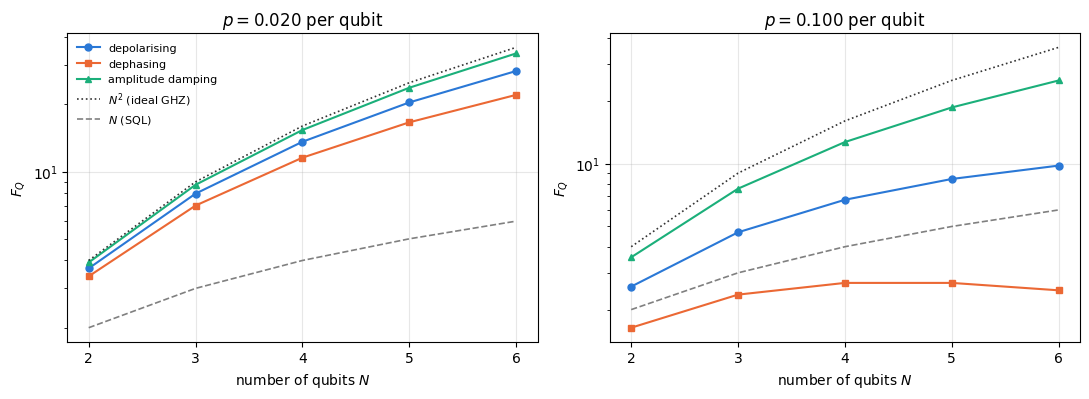

In [21]:
# ==============================================================================
# FIGURE: at fixed p, how fast does the advantage die with N?
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.1))
Nn = np.array([2, 3, 4, 5, 6])
for j, p_show in enumerate((0.02, 0.10)):
    ip = int(np.argmin(np.abs(P_GRID - p_show)))
    for k, cname in enumerate(CHANNELS):
        axes[j].semilogy(Nn, [noise_data[(cname, N)][ip] for N in Nn], MARKERS[k] + "-",
                         color=PALETTE[k], ms=5, label=cname)
    axes[j].semilogy(Nn, Nn ** 2.0, ":", color="0.2", lw=1.2, label=r"$N^2$ (ideal GHZ)")
    axes[j].semilogy(Nn, Nn * 1.0, "--", color="0.5", lw=1.2, label=r"$N$ (SQL)")
    axes[j].set_xlabel("number of qubits $N$"); axes[j].set_ylabel(r"$F_Q$")
    axes[j].set_title(f"$p = {P_GRID[ip]:.3f}$ per qubit"); axes[j].set_xticks(Nn)
axes[0].legend(fontsize=8)
fig.tight_layout(); plt.show()

In [22]:
# ==============================================================================
# STEP 11b: comparing two channels at the SAME physical strength, not the same label p
# ==============================================================================
# A single qubit under dephasing(p) keeps a fraction (1 - 2p) of its transverse Bloch components;
# under depolarising(p) it keeps (1 - 4p/3).  Matching those two contractions to a common value eta
# removes the parametrisation convention from the comparison and leaves only physics.
print("GHZ_N, G = J_z: dephasing vs depolarising at EQUAL transverse Bloch contraction eta\n")
print(f"{'eta':>5s} {'p(deph)':>8s} {'p(depol)':>9s} | " + " ".join(f"{'N=%d' % N:>21s}" for N in (2, 4, 6)))
print(f"{'':>5s} {'':>8s} {'':>9s} | " + " ".join(f"{'deph':>7s}{'depol':>8s}{'ratio':>6s}" for _ in (2, 4, 6)))
for eta in (0.98, 0.90, 0.80):
    p_deph, p_depol = (1 - eta) / 2, 3 * (1 - eta) / 4
    cells = []
    for N in (2, 4, 6):
        a = float(qfi_noisy(apply_local_channel(to_dm(ghz_state(N)), kraus_dephasing, p_deph), (0, 0, 1), N)) / N ** 2
        b = float(qfi_noisy(apply_local_channel(to_dm(ghz_state(N)), kraus_depolarizing, p_depol), (0, 0, 1), N)) / N ** 2
        cells.append(f"{a:7.4f}{b:8.4f}{b / a:6.2f}")
        assert abs(a - (1 - 2 * p_deph) ** (2 * N)) < 1e4 * TOL      # the dephasing column is still Eq. (23)
        assert b > a - 1e-12                                          # depolarising is never the harsher of the two
    print(f"{eta:5.2f} {p_deph:8.3f} {p_depol:9.3f} | " + " ".join(cells))

GHZ_N, G = J_z: dephasing vs depolarising at EQUAL transverse Bloch contraction eta

  eta  p(deph)  p(depol) |                   N=2                   N=4                   N=6
                         |    deph   depol ratio    deph   depol ratio    deph   depol ratio


 0.98    0.010     0.015 |  0.9224  0.9410  1.02  0.8508  0.8857  1.04  0.7847  0.8335  1.06


 0.90    0.050     0.075 |  0.6561  0.7250  1.10  0.4305  0.5285  1.23  0.2824  0.3842  1.36


 0.80    0.100     0.150 |  0.4096  0.4995  1.22  0.1678  0.2557  1.52  0.0687  0.1293  1.88


The dephasing panel confirms Eq. (23) exactly (the numerical points lie on the dashed analytic curves, and the checkpoint
asserts agreement to $10^{-14}$ relative or better). All three channels behave the same way qualitatively: at fixed
per-qubit error probability the ratio $F_Q/N^2$ falls with $N$, so the curves for larger $N$ lie *below* the smaller ones.
Concretely, at $p=0.02$ (a very good gate) the dephased $N=6$ GHZ retains $F_Q/N^2=0.61$, while at $p=0.10$ it is down to
$0.069$. The right-hand figure shows what this means in absolute terms: at $p=0.10$ the *dephased* GHZ state sits below
the standard quantum limit at every $N$ shown, and its $F_Q$ stops growing altogether around $N\approx4$ (indeed
$N^2(1-2p)^{2N}$ is maximised at $N=-1/\ln(1-2p)\approx4.5$ and decreases beyond it); the depolarised state still grows,
but far more slowly than $N^2$.

At equal nominal $p$ the measured ordering is the same at every $N$ and every $p$ we tried: **amplitude damping is the
gentlest, depolarising is intermediate, dephasing is the harshest** (at $N=6$, $p=0.05$: $0.85$, $0.54$, $0.28$ of the
ideal value). Part of that ordering is bookkeeping and part of it is physics, and the two must be separated.

**The bookkeeping.** Equal $p$ does not mean equal physical strength. A single qubit under our dephasing channel keeps a
fraction $1-2p$ of its transverse Bloch components; under our depolarising channel it keeps $1-4p/3$, because the $X$ and
$Y$ errors destroy transverse coherence just as the $Z$ error does — the correct convention factor is $3/2$, not the $3$
one would guess from "$Z$ with probability $p/3$". Matching the two contractions, $p_{\text{depol}}=\tfrac32 p_{\text{deph}}$,
is what STEP 11b does.

**The physics that is left.** Even at matched contraction the depolarising channel is the milder of the two, and the gap
*grows* with $N$ and with noise strength: the measured ratio $F_Q^{\text{depol}}/F_Q^{\text{deph}}$ runs from $1.02$ at
$\eta=0.98$, $N=2$ to $1.88$ at $\eta=0.80$, $N=6$. The reason is visible in the structure of the two states. Local
dephasing keeps all the weight in the single two-dimensional block spanned by $\vert0\cdots0\rangle$ and
$\vert1\cdots1\rangle$ and merely shrinks its coherence, which is why Eq. (23) is exact. Local depolarising also flips
bits, and a flip on qubit $q$ maps the pair $(\vert0\cdots0\rangle,\vert1\cdots1\rangle)$ onto another *complementary*
pair $(\vert s\rangle,\vert\bar s\rangle)$. The state therefore stays block diagonal in complementary pairs, and each
block is again a small cat, with $J_z$ eigenvalues $\pm(N-2w_s)/2$ instead of $\pm N/2$, where $w_s$ is the number of
ones in $s$. Those blocks contribute less than the top one but not zero, and their contributions are what the
depolarising channel retains and the dephasing channel does not.

Amplitude damping is milder again, for a third reason: it drives the state towards $\vert0\cdots0\rangle$, which is an
eigenstate of $J_z$ with an extreme eigenvalue, so part of the structure that carries the phase survives the decay.
What is convention-independent — and what matters for an experiment — is the exponential-in-$N$ decay shared by all three.

> **Physics insight.** This is the central practical tension of quantum metrology. The GHZ state has the maximum possible
> $F_Q$ and the minimum possible robustness: a coherence spread over $N$ qubits decays $N$ times faster than a single-qubit
> coherence. Notebook 32 turns this into a statement about the *optimal* interrogation time, and notebook 33 shows that
> moderately squeezed states — with $F_Q$ between $N$ and $N^2$ — are the practical sweet spot.

## 14. Losing particles: the QFI of a subsystem, and Schmidt compression

A different and equally common imperfection: the phase is imprinted on all $N$ qubits, but only $K$ of them reach the
detector — atoms escape the trap, photons are lost, a detector goes dark. What survives is the reduced state

$$\rho_A(\theta)=\mathrm{Tr}_B\left[U(\theta)\vert\psi\rangle\langle\psi\vert U^\dagger(\theta)\right],$$

a *mixed* state of the $K$ kept qubits. Its QFI is what an experiment can still achieve.

### 14.1 The reduced derivative without ever building $\rho_A(\theta)$

Because the partial trace is linear and $\partial_\theta\rho=-i[G,\rho]$,

$$\partial_\theta\rho_A=\mathrm{Tr}_B\left(-i\left[G,\rho\right]\right)
 =-i\,\mathrm{Tr}_B\Big(G\vert\psi\rangle\langle\psi\vert-\vert\psi\rangle\langle\psi\vert G\Big).$$

Now use the matrix view of a bipartite state (the Schmidt trick of
[06 — states, observables, entanglement](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb)):
reshape the tensor $\psi$ into a matrix $\Psi$ of shape $(d_A,d_B)$ with $d_A=2^K$, $d_B=2^{N-K}$, and reshape
$\vert\phi\rangle=G\vert\psi\rangle$ into $\Phi$ the same way. Partial traces become matrix products:

$$\rho_A=\Psi\Psi^\dagger,\qquad \mathrm{Tr}_B\left(\vert\phi\rangle\langle\psi\vert\right)=\Phi\Psi^\dagger,$$

so, with $T=\Phi\Psi^\dagger$,

$$\rho_A=\Psi\Psi^\dagger,\qquad \partial_\theta\rho_A=-i\left(T-T^\dagger\right). \tag{24}$$

Feed the pair into the SLD formula in its general form (the one derived in notebook 30),

$$F_Q=2\sum_{m,n\,:\,\lambda_m+\lambda_n>0}\frac{\left\vert\langle m\vert\partial_\theta\rho_A\vert n\rangle\right\vert^2}{\lambda_m+\lambda_n}, \tag{25}$$

and we are done. (Equation (22) is Eq. (25) specialised to a *full* state with unitary encoding; for a subsystem the
generator no longer acts inside $A$ alone, so we must use the derivative itself.)

### 14.2 Schmidt compression: making $K=N-1$ as cheap as $K=1$

Equation (25) needs an eigendecomposition of $\rho_A$, costing $O(d_A^3)=O(8^K)$. Losing *one* qubit would then be the
most expensive case, even though losing one qubit barely mixes the state. The cure is the **Schmidt rank bound**:
for a pure $\vert\psi\rangle$, $\;\mathrm{rank}(\rho_A)\le\min(d_A,d_B)$. Moreover both $\rho_A$ and $\partial_\theta\rho_A$
from Eq. (24) have all their rows and columns inside the span of the columns of $\Psi$ and $\Phi$ — a subspace of
dimension at most $2d_B$. So:

1. stack $B=\left[\;\Psi\;\;\Phi\;\right]$, of shape $(d_A,2d_B)$;
2. compute a thin QR decomposition $B=QR$; the columns of $Q$ (at most $2d_B$ of them) span the **active subspace**;
3. project, $\tilde\Psi=Q^\dagger\Psi$, $\tilde\Phi=Q^\dagger\Phi$, and rebuild $\rho_A$, $\partial_\theta\rho_A$ there;
4. diagonalise the small matrices.

The projection is an isometry, so the non-zero eigenvalues of $\rho_A$ and all the matrix elements in Eq. (25) are
unchanged, and the eigendecomposition drops from $O(8^{K})$ to $O(8^{N-K})$. Combining the two branches, the
diagonalisation costs $O\!\left(8^{\min(K,\,N-K)}\right)$: symmetric around the middle cut, as it should be. Two cheaper
terms remain in every case and set the floor of the measured timings in Section 15: applying the generator, $O(N2^N)$,
and the QR plus the projections, $O(2^K4^{N-K})$.

In [23]:
# ==============================================================================
# STEP 12: QFI of a subsystem, with and without Schmidt (QR) compression
# ==============================================================================
def qfi_from_derivative(rho, drho, tol=1e-12):
    """General SLD quantum Fisher information from a state and its derivative, Eq. (25).

    MATH   F_Q = 2 sum_{m,n} |<m|drho|n>|^2 / (lam_m + lam_n),  summed over lam_m + lam_n > tol,
           with rho = sum_m lam_m |m><m|.   (Derived in notebook 30.)
    COST   one Hermitian eigendecomposition, O(d^3).
    """
    lam, v = jnp.linalg.eigh(rho)
    D = v.conj().T @ drho @ v
    den = lam[:, None] + lam[None, :]
    ok = den > tol
    return 2 * jnp.sum(jnp.where(ok, jnp.abs(D) ** 2 / jnp.where(ok, den, 1.0), 0.0))


def subsystem_qfi(psi, n_dir, K, compress=True, tol=1e-12):
    """QFI of the reduced state of the FIRST K qubits after encoding with G = n.J on all N qubits.

    MATH   Psi  = psi reshaped to (2^K, 2^{N-K}),   Phi = (G psi) reshaped the same way;
           rho_A = Psi Psi^dag,   d rho_A/d theta = -i (T - T^dag) with T = Phi Psi^dag     [Eq. (24)]
    IMPLEMENTATION  when 2^K > 2^{N-K} the two matrices span a subspace of dimension <= 2^{N-K+1};
           a thin QR of [Psi | Phi] gives an isometry Q onto it, and everything is done inside.
    COST   O(8^min(K, N-K)) for the eigendecomposition instead of O(8^K).
    """
    P = pauli_direction(n_dir)
    phi = 0.5 * apply_collective(psi, P)                      # |phi> = (n.J)|psi>, matrix-free
    Psi = psi.reshape(2 ** K, -1)
    Phi = phi.reshape(2 ** K, -1)
    if compress and Psi.shape[0] > Psi.shape[1]:
        Q, _ = jnp.linalg.qr(jnp.concatenate([Psi, Phi], axis=1))     # thin QR: active subspace
        Psi, Phi = Q.conj().T @ Psi, Q.conj().T @ Phi
    rho_A = Psi @ Psi.conj().T
    T = Phi @ Psi.conj().T
    return qfi_from_derivative(rho_A, -1j * (T - T.conj().T), tol)


# --- CHECKPOINT 1: no loss (K = N) must reproduce 4 Var(G) --------------------------
for name, psi, n in (("GHZ(6)", ghz_state(6), (0, 0, 1)), ("W(6)", w_state(6), (1, 0, 0)),
                     ("Haar(6)", haar_state(jax.random.PRNGKey(2), 6), (0, 0, 1))):
    a = float(subsystem_qfi(psi, n, 6))
    b = float(qfi_pure_direction(psi, n))
    print(f"K=N check {name:9s}: subsystem formula {a:12.8f}   4 Var(G) {b:12.8f}   err {abs(a - b):.2e}")
    assert abs(a - b) < 1e4 * TOL

# --- CHECKPOINT 2: compressed vs uncompressed, and vs an independent brute-force route ------
psi_t = haar_state(jax.random.PRNGKey(4), 7)
print()
for K in (2, 4, 6):
    a = float(subsystem_qfi(psi_t, (0, 0, 1), K, compress=True))
    b = float(subsystem_qfi(psi_t, (0, 0, 1), K, compress=False))
    # brute force: build rho_A(theta) explicitly and differentiate it with jax.jacfwd
    def rho_A_of_theta(th, K=K):
        U = jnp.cos(th / 2) * I2 - 1j * jnp.sin(th / 2) * Z
        p = psi_t
        for q in range(7):
            p = apply_gate(p, U, [q])
        return rdm(p, range(K))
    c = float(qfi_from_derivative(rho_A_of_theta(0.0), jax.jacfwd(rho_A_of_theta)(0.0)))
    print(f"K={K}: compressed {a:.10f}  uncompressed {b:.10f}  jacfwd brute force {c:.10f}  "
          f"max err {max(abs(a - b), abs(a - c)):.2e}")
    assert max(abs(a - b), abs(a - c)) < 1e4 * TOL

K=N check GHZ(6)   : subsystem formula  36.00000000   4 Var(G)  36.00000000   err 0.00e+00
K=N check W(6)     : subsystem formula  16.00000000   4 Var(G)  16.00000000   err 2.66e-14
K=N check Haar(6)  : subsystem formula   6.77522856   4 Var(G)   6.77522856   err 1.78e-15


K=2: compressed 0.0846140897  uncompressed 0.0846140897  jacfwd brute force 0.0846140897  max err 0.00e+00


K=4: compressed 2.1999559741  uncompressed 2.1999559741  jacfwd brute force 2.1999559741  max err 1.33e-15


K=6: compressed 5.7844875410  uncompressed 5.7844875410  jacfwd brute force 5.7844875410  max err 3.55e-15


Three independent implementations agree: the compressed and uncompressed versions of Eq. (24)–(25), and a brute-force
route that applies the encoding $e^{-i\theta Z/2}$ gate by gate with `apply_gate`, traces out the lost qubits with `rdm`,
and differentiates the resulting $\rho_A(\theta)$ at $\theta=0$ with forward-mode automatic differentiation
(`jax.jacfwd` propagates one tangent through the whole computation; no finite differences and no step size). The last
check is the important one: it tests the claim that the derivative of the reduced state is $-i(T-T^\dagger)$, the only
non-obvious step of the derivation, and it does so without using `apply_collective` at all — so it also validates the
matrix-free generator that Sections 8–12 relied on.

In [24]:
# ==============================================================================
# STEP 13: how much QFI survives the loss of k qubits?
# ==============================================================================
N_LOSS = 8
loss_states = [("GHZ", ghz_state(N_LOSS), (0, 0, 1)),
               ("W", w_state(N_LOSS), (1, 0, 0)),
               ("Dicke N/2", dicke_state(N_LOSS, N_LOSS // 2), (1, 0, 0)),
               ("|+>^N", product_state("+" * N_LOSS), (0, 1, 0)),
               ("cluster", cluster_state(N_LOSS), (0, 0, 1)),
               ("Haar", haar_state(jax.random.PRNGKey(1), N_LOSS), (0, 0, 1))]
loss_tab = {}
print(f"N = {N_LOSS}:  QFI of the reduced state of the first {N_LOSS}-k qubits\n")
print(f"{'state':>12s} | " + " ".join(f"k={k:<7d}" for k in range(N_LOSS)))
for name, psi, n in loss_states:
    vals = [float(subsystem_qfi(psi, n, N_LOSS - k)) for k in range(N_LOSS)]
    loss_tab[name] = np.array(vals)
    print(f"{name:>12s} | " + " ".join(f"{v:8.4f} " for v in vals))

N = 8:  QFI of the reduced state of the first 8-k qubits

       state | k=0       k=1       k=2       k=3       k=4       k=5       k=6       k=7      


         GHZ |  64.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000    0.0000 
           W |  22.0000   14.4375    9.0000    5.3125    3.0000    1.6875    1.0000    0.5625 
   Dicke N/2 |  40.0000   15.0000    8.1818    4.7959    2.8313    1.5306    0.6494    0.0000 


       |+>^N |   8.0000    7.0000    6.0000    5.0000    4.0000    3.0000    2.0000    1.0000 
     cluster |   8.0000    6.0000    5.0000    4.0000    3.0000    2.0000    1.0000    0.0000 
        Haar |   7.8220    6.6000    5.3728    4.0040    1.5709    0.3737    0.0667    0.0238 


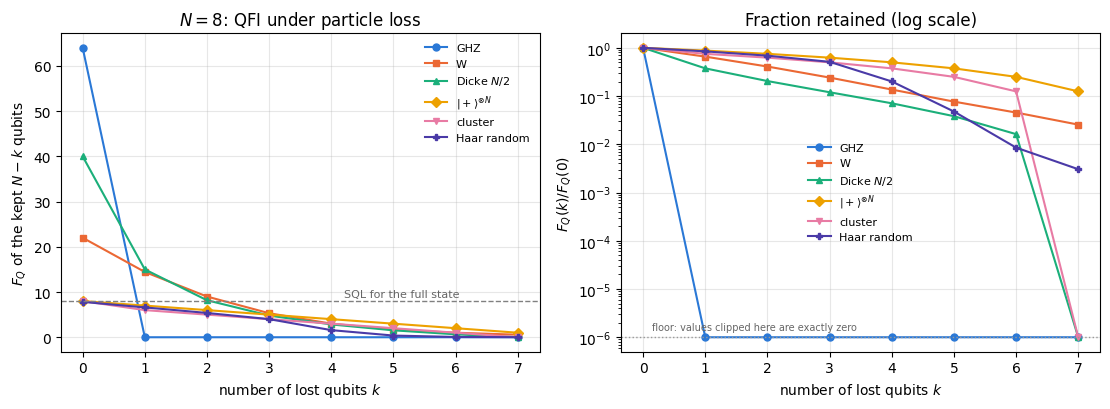

In [25]:
# ==============================================================================
# FIGURE: metrological power lost with the particles
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2))
ks = np.arange(N_LOSS)
for j, (name, psi, n) in enumerate(loss_states):
    axes[0].plot(ks, loss_tab[name], MARKERS[j % 6] + "-", color=PALETTE[j % 6], ms=5, label=LBL[name])
    axes[1].semilogy(ks, np.clip(loss_tab[name] / max(loss_tab[name][0], 1e-12), 1e-6, None),
                     MARKERS[j % 6] + "-", color=PALETTE[j % 6], ms=5, label=LBL[name])
axes[1].axhline(1e-6, color="0.6", ls=":", lw=1)
axes[1].text(0.15, 1.4e-6, "floor: values clipped here are exactly zero", fontsize=7, color="0.4")
axes[0].axhline(N_LOSS, color="0.5", ls="--", lw=1)
axes[0].text(4.2, N_LOSS * 1.1, "SQL for the full state", fontsize=8, color="0.4")
axes[0].set_xlabel("number of lost qubits $k$"); axes[0].set_ylabel(r"$F_Q$ of the kept $N-k$ qubits")
axes[0].set_title(f"$N={N_LOSS}$: QFI under particle loss"); axes[0].legend(fontsize=8)
axes[1].set_xlabel("number of lost qubits $k$"); axes[1].set_ylabel(r"$F_Q(k)/F_Q(0)$")
axes[1].set_title("Fraction retained (log scale)"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

The GHZ curve drops discontinuously: losing a **single** qubit takes $F_Q$ from $N^2=64$ to exactly $0$.
The reason is transparent from Eq. (24). Tracing out one qubit of a GHZ state leaves
$\rho_A=\tfrac12\left(\vert0\cdots0\rangle\langle0\cdots0\vert+\vert1\cdots1\rangle\langle1\cdots1\vert\right)$ — a
*classical* mixture of two $J_z$ eigenstates. A mixture of eigenstates of the generator does not move at all when the
generator acts, so $\partial_\theta\rho_A=0$ and no measurement on the survivors can say anything about $\theta$.
All of the GHZ phase information is stored in a single global coherence, and a single lost particle carries it away.

Everything else degrades gracefully. The **W** state loses a roughly constant factor of about $0.6$ per lost qubit
($22\to14.44\to9.00\to5.31\to\ldots$); the **Dicke** state pays a steep price for the first loss ($40\to15$) and then
settles into a similar geometric decay; the **product** state loses exactly one unit of QFI per qubit
($F_Q=N-k$, as it must, since the survivors are just $N-k$ independent qubits); the cluster and Haar states interpolate,
with the Haar state falling off a cliff of its own once more than half the qubits are gone — a random state stores its
information in correlations that need most of the system to be read out. For a resource that must survive real
detectors, *graceful* beats *maximal*. (In the right-hand panel, curves that touch the floor at $10^{-6}$ are exactly
zero: GHZ from $k=1$ on, cluster and Dicke at $k=7$.)

> **Physics insight.** This is the quantitative version of the folklore "GHZ states are fragile, Dicke and squeezed states
> are robust". Notebook 37 revisits it as a systematic study of QFI versus particle loss, and notebook 34 shows where along
> a one-axis-twisting evolution the trade-off is best.

## 15. Performance: the total cost

Three regimes, three scalings:

| quantity | algorithm | time | memory |
|---|---|---|---|
| $F_Q$ of a pure state | `qfi_pure`: $N$ einsums plus two inner products | $O(N2^N)$ | $O(2^N)$ |
| $3\times3$ QFI matrix | three collective applications plus a $3\times3$ `eigh` | $O(N2^N)$ | $O(2^N)$ |
| $F_Q$ of a mixed state, Eq. (22) | dense eigendecomposition of $\rho$ | $O(8^N)$ | $O(4^N)$ |
| $F_Q$ of a subsystem, compressed | thin QR plus a small `eigh` | $O\!\left(8^{\min(K,N-K)}\right)$ | $O(2^N)$ |

Let us measure the first and the last, separating compile time from run time as always.

In [26]:
# ==============================================================================
# STEP 14: measured cost of the matrix-free QFI, and of Schmidt compression
# ==============================================================================
print("Pure-state QFI, F_Q = 4 Var(J_z), matrix-free (jit-compiled)\n")
print(f"{'N':>3s} {'dim 2^N':>9s} | {'compile [ms]':>13s} {'run [ms]':>10s} {'F_Q':>10s}")
qfi_rows = []
for N in (6, 8, 10, 12, 14, 16):
    f = jax.jit(lambda p: qfi_pure(p, Z))
    val, tc, tr = timed(f, ghz_state(N))
    qfi_rows.append((N, tc, tr))
    print(f"{N:3d} {2 ** N:9d} | {tc * 1e3:13.1f} {tr * 1e3:10.3f} {float(val):10.1f}")

print("\nSubsystem QFI at N=12, keeping K qubits: compression on and off\n")
print(f"{'K':>3s} {'d_A':>7s} {'d_B':>6s} | {'compressed run [ms]':>20s} {'naive run [ms]':>16s} {'speed-up':>9s}")
psi12 = haar_state(jax.random.PRNGKey(2), 12)
comp_rows = []
for K in (2, 4, 6, 8, 9, 10, 11):
    fc = jax.jit(partial(subsystem_qfi, n_dir=(0, 0, 1), K=K, compress=True))
    _, _, tr_c = timed(fc, psi12)
    if K <= 9:                                     # the naive route becomes painfully slow beyond this
        fn = jax.jit(partial(subsystem_qfi, n_dir=(0, 0, 1), K=K, compress=False))
        _, _, tr_n = timed(fn, psi12)
    else:
        tr_n = float("nan")
    comp_rows.append((K, tr_c, tr_n))
    print(f"{K:3d} {2 ** K:7d} {2 ** (12 - K):6d} | {tr_c * 1e3:20.3f} {tr_n * 1e3:16.3f} {tr_n / tr_c:9.1f}")

Pure-state QFI, F_Q = 4 Var(J_z), matrix-free (jit-compiled)

  N   dim 2^N |  compile [ms]   run [ms]        F_Q


  6        64 |         286.0      0.657       36.0


  8       256 |         328.4      0.622       64.0


 10      1024 |         370.3      0.675      100.0


 12      4096 |         779.8      0.848      144.0


...

  6      64     64 |               79.584          143.964       1.8


  8     256     16 |               20.263         4004.011     197.6


  9     512      8 |                0.937         6447.445    6879.3


 10    1024      4 |                0.996              nan       nan


 11    2048      2 |                1.836              nan       nan


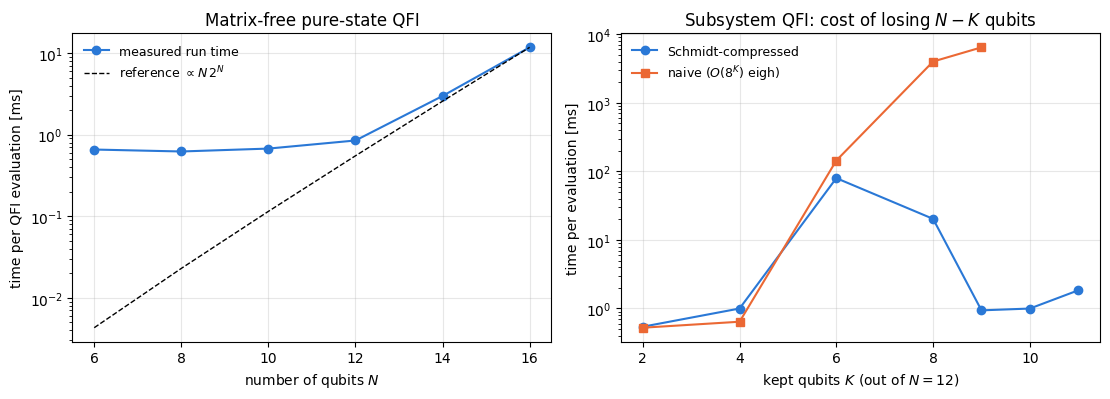

In [27]:
# ==============================================================================
# FIGURE: measured scaling
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.1))
Nq = np.array([r[0] for r in qfi_rows], dtype=float)
tq = np.array([r[2] for r in qfi_rows]) * 1e3
axes[0].semilogy(Nq, tq, "o-", color=PALETTE[0], label="measured run time")
ref = tq[-1] * (Nq / Nq[-1]) * 2.0 ** (Nq - Nq[-1])
axes[0].semilogy(Nq, ref, "k--", lw=1, label=r"reference $\propto N\,2^N$")
axes[0].set_xlabel("number of qubits $N$"); axes[0].set_ylabel("time per QFI evaluation [ms]")
axes[0].set_title("Matrix-free pure-state QFI"); axes[0].legend(fontsize=9)

Kk = np.array([r[0] for r in comp_rows], dtype=float)
axes[1].semilogy(Kk, np.array([r[1] for r in comp_rows]) * 1e3, "o-", color=PALETTE[0], label="Schmidt-compressed")
mask = ~np.isnan([r[2] for r in comp_rows])
axes[1].semilogy(Kk[mask], np.array([r[2] for r in comp_rows])[mask] * 1e3, "s-", color=PALETTE[1],
                 label=r"naive ($O(8^K)$ eigh)")
axes[1].set_xlabel("kept qubits $K$ (out of $N=12$)"); axes[1].set_ylabel("time per evaluation [ms]")
axes[1].set_title("Subsystem QFI: cost of losing $N-K$ qubits"); axes[1].legend(fontsize=9)
fig.tight_layout(); plt.show()

Read the left panel as a comparison of *slopes*, not of values — the dashed reference is only fixed up to a constant, and
it has been anchored at the last point. Below $N\approx10$ the measured curve is almost flat: the arithmetic there is
faster than the fixed cost of dispatching a compiled program from Python (a few tens of microseconds), so the
measurement reports the overhead, not the algorithm. Above $N\approx10$ it turns over and climbs steadily, but its slope
stays somewhat *below* the $N2^N$ reference: each additional pair of qubits costs a factor $3$–$4$ rather than the
$4\,(N+2)/N\approx4.7$ that counting operations predicts. Two effects push the same way — the constant overhead has not
fully disappeared even at $N=12$, and the largest einsums are the first ones big enough for XLA to spread across several
cores. The lesson is the one every benchmark teaches: an $O(\cdot)$ is a statement about arithmetic, a timing is a
statement about one machine, and they coincide only in the window where neither dispatch nor parallelism dominates.
At $N=16$ (a $65\,536$-dimensional space) one QFI evaluation still takes only a few milliseconds, so a sweep over hundreds
of parameters is a matter of seconds. Compare that with the dense alternative: a $2^{16}\times2^{16}$ complex matrix
would need $68$ GB.

The right panel is the point of Schmidt compression. Without it the cost rises steeply with the number of *kept* qubits and
becomes unusable near $K=N$ — precisely the physically interesting regime of losing one or two particles. With compression
the run time is essentially flat in $K$; the two curves coincide for $K\le6$ (where $d_A\le d_B$ and the compression branch
is not taken at all) and separate sharply afterwards, reaching the speed-up printed above at $K=9$. At $K=11$ the naive
route would have to diagonalise a $2048\times2048$ matrix that we know in advance has rank at most $2$.

> **Numerical practice.** Whenever a matrix is built as $\Psi\Psi^\dagger$ from a tall-and-thin $\Psi$, its rank is bounded
> by the thin dimension. Never hand such a matrix to a general eigensolver — project onto the column span first. The same
> idea appears as "low-rank updates" in optimisation and as "active subspace" methods in uncertainty quantification.

## 16. Key takeaways

* **Estimation is a statistics problem with a quantum input.** An estimator has bias and variance; the Fisher information
  $I(\theta)=\sum_x(\partial_\theta p)^2/p$ of the outcome distribution bounds the variance of any *unbiased* estimator by
  $\mathrm{Var}\ge1/I$ (Cauchy–Schwarz, Section 5.1), the Fisher information of $M$ independent repetitions is $MI$, and
  maximum likelihood reaches the bound asymptotically — which we measured, seeing $M\,\mathrm{Var}\to1/I$ from about
  $M\approx30$ onwards.
* **The quantum Fisher information is the best measurement's Fisher information**, $F_Q=\max_{\{E_x\}}I(\theta;\{E_x\})$
  (Braunstein–Caves), hence $\Delta\theta\ge1/\sqrt{MF_Q}$. It is a property of the state and of the generator only.
* **For pure states with unitary encoding, $F_Q=4\,\mathrm{Var}(G)$** — derived twice, from the SLD and from the overlap
  expansion, and independent of $\theta$. Matrix-free it costs $O(N2^N)$: apply $G$ once, take two inner products.
* **Two limits, both proved.** Product states obey $F_Q\le N$ (variances of independent qubits add, each at most $1/4$);
  every state obeys $F_Q\le N^2$ (the spectrum of $J_{\mathbf n}$ has width $N$), and GHZ saturates it.
* **The state alone does not decide.** $F_Q$ is a property of the pair (state, generator). The $3\times3$ matrix
  $\mathcal F_{ab}=4C_{ab}$ makes the direction dependence explicit, $F_Q(\mathbf n)=\mathbf n^{\mathsf T}\mathcal F\mathbf n$,
  and the optimum over the sphere is the largest eigenvalue of a $3\times3$ matrix — one `eigh`, no optimisation.
* **Entanglement is necessary but not sufficient.** $F_Q>\lfloor N/k\rfloor k^2+(N\bmod k)^2$ certifies entanglement
  depth $k+1$; yet Haar-random states (maximal entropy) sit exactly at $F_Q\approx N$, and the cluster state only beats $N$ by a boundary term.
  Metrology rewards macroscopic coherent superpositions, not entanglement volume.
* **Noise and loss destroy the Heisenberg limit.** Dephased GHZ obeys $F_Q=N^2(1-2p)^{2N}$ exactly — the advantage
  dies exponentially in $N$ — and losing one single qubit of a GHZ state sets $F_Q$ to exactly zero. States that degrade
  gracefully (Dicke, squeezed) are what real experiments use.
* **Implementation.** Validate every new quantity against at least two independent routes before plotting it (we used
  matrix-free, dense, SLD, finite differences and `jax.jacfwd`); exploit rank structure (Schmidt compression turned an
  $O(8^K)$ eigendecomposition into an $O(8^{N-K})$ one, two orders of magnitude at $K=9$, $N=12$).

## 17. Exercises

1. ★ **Read the bound.** A magnetometer uses $N=100$ atoms and $M=10^4$ repetitions. Compute the smallest phase
   uncertainty $\Delta\theta$ allowed at the standard quantum limit and at the Heisenberg limit, and the factor between
   them. Then use Eq. (23) to find the per-qubit dephasing probability $p$ at which the GHZ advantage is entirely lost,
   i.e. at which $N^2(1-2p)^{2N}=N$.
2. ★ **Fisher information of a tilted readout.** For the single qubit of Section 7.4, compute analytically and then with
   `fisher_information_ad` the Fisher information of a measurement along the direction
   $\mathbf m=(\cos\alpha,\sin\alpha,0)$ in the equatorial plane. Show that $p(\pm)=\left(1\pm\cos(\theta-\alpha)\right)/2$
   and that $I(\theta)$ is the *same* for every $\alpha$, so that a whole family of readouts saturates the quantum
   Cramér–Rao bound. Then set $\alpha=\theta$, so that the fringe sits at an extremum: what does
   `fisher_information_ad` return, what is the limit of $I$ as $\alpha\to\theta$, and which of the two conditions of
   Section 5.2 has been violated?
3. ★★ **Dicke states are a family (physics).** Compute $F_Q$ for $\vert D_N^k\rangle$ with $G=J_x$ for all
   $k=0,\dots,N$ at $N=10$ and plot it against $k$. Derive the closed form from
   $\langle J_x^2\rangle=\tfrac12[j(j+1)-m^2]$ with $j=N/2$, $m=N/2-k$, and check your formula against the numbers.
   Which $k$ is optimal and why is $k=N/2$ not a coincidence?
4. ★★ **Superposition of the useless (extend the code).** Take two Haar-random states $\vert\psi_1\rangle,\vert\psi_2\rangle$
   at $N=8$ and compute $F_Q$ of $(\vert\psi_1\rangle+e^{i\varphi}\vert\psi_2\rangle)/\mathcal N$ for $\varphi\in[0,2\pi)$.
   Two metrologically useless states — how useful can their superposition be? Then repeat with the *pair*
   $\vert0\cdots0\rangle$ and $\vert1\cdots1\rangle$, each of which has $F_Q=0$ for $G=J_z$. Explain both results with
   Eq. (14): what property of the two summands decides whether the superposition gains anything?
5. ★★ **Optimal direction along a twisting evolution (extend the code).** Evolve $\vert+\rangle^{\otimes N}$ with the
   engine's `oat_evolve` for a range of twisting times, and plot $\lambda_{\max}(\mathcal F)$ together with the three
   Cartesian values $F_Q(J_x),F_Q(J_y),F_Q(J_z)$. By how much does choosing the optimal direction beat the best Cartesian
   one? (This is a preview of notebook 34.)
6. ★★ **Noise before or after (extend the code).** Section 13 applied the channel *before* the encoding. Redo the
   dephasing sweep with the channel applied *after* $U(\theta)$ and compare. Then do the same for $G=J_x$ instead of
   $G=J_z$. Which combinations give identical results, and what property of the channel explains it? (Notebook 30 answers
   this in detail — try to get there first.)
7. ★★★ **The cluster state's boundary (physics).** We found $\lambda_{\max}(\mathcal F)=N+2$ for the open cluster chain.
   Verify that the excess disappears for the *periodic* cluster state (`cluster_state(N, periodic=True)`), identify the
   stabiliser responsible for the off-diagonal elements of $\mathcal F$ in the open chain, and confirm your explanation by
   computing the relevant correlator with `expect_pauli_string`.
8. ★★★ **A better lossy resource (extend the code).** Search numerically for the pure symmetric state of $N=8$ qubits that
   maximises $F_Q$ of the reduced state *after losing one qubit*. Parametrise a state in the symmetric (Dicke) subspace by
   $N+1$ complex amplitudes, use `jax.grad` on `subsystem_qfi` and Adam, and compare the optimum with GHZ, with
   $\vert D_N^{N/2}\rangle$, and with the ideal $F_Q=N^2$. How much of the Heisenberg advantage can survive one lost particle?
   *Hint on the numerics:* `subsystem_qfi` differentiates through `jnp.linalg.eigh`, whose gradient is undefined when two
   eigenvalues coincide. Starting from a random complex vector of amplitudes the gradient is finite, but a symmetric
   starting point such as GHZ sits exactly on a degeneracy and returns `nan`; start away from it, and check
   `jnp.isfinite` on the gradient before feeding it to the optimiser.

## References

* C. W. Helstrom, *Quantum Detection and Estimation Theory* (Academic Press, New York, 1976) — the book that founded
  quantum estimation theory; the symmetric logarithmic derivative and the quantum Cramér–Rao bound.
* S. L. Braunstein and C. M. Caves, *Statistical distance and the geometry of quantum states*,
  Phys. Rev. Lett. **72**, 3439 (1994) — the theorem of Section 6.1: the quantum Fisher information is the maximum of the
  classical Fisher information over all measurements, attained in the eigenbasis of the SLD.
* V. Giovannetti, S. Lloyd and L. Maccone, *Quantum-enhanced measurements: beating the standard quantum limit*,
  Science **306**, 1330 (2004), and *Quantum metrology*, Phys. Rev. Lett. **96**, 010401 (2006) — the standard quantum
  limit versus the Heisenberg limit.
* L. Pezzè and A. Smerzi, *Entanglement, nonlinear dynamics, and the Heisenberg limit*,
  Phys. Rev. Lett. **102**, 100401 (2009) — Eq. (20): $F_Q>N$ witnesses entanglement.
* P. Hyllus, W. Laskowski, R. Krischek, C. Schwemmer, W. Wieczorek, H. Weinfurter, L. Pezzè and A. Smerzi,
  *Fisher information and multiparticle entanglement*, Phys. Rev. A **85**, 022321 (2012), and
  G. Tóth, *Multipartite entanglement and high-precision metrology*, Phys. Rev. A **85**, 022322 (2012) — Eq. (21),
  the entanglement-depth bound for $k$-producible states.
* M. G. A. Paris, *Quantum estimation for quantum technology*, Int. J. Quantum Inf. **7**, 125–137 (2009) — a compact and
  very readable review of everything in Sections 3–7.
* L. Pezzè, A. Smerzi, M. K. Oberthaler, R. Schmied and P. Treutlein, *Quantum metrology with nonclassical states of
  atomic ensembles*, Rev. Mod. Phys. **90**, 035005 (2018) — the standard modern review; collective spins, Dicke states,
  squeezing, experiments.
* G. Tóth and I. Apellaniz, *Quantum metrology from a quantum information science perspective*,
  J. Phys. A **47**, 424006 (2014) — the entanglement-witness side of the QFI, with proofs of the convexity and of the
  $k$-producibility bounds.
* H. Cramér, *Mathematical Methods of Statistics* (Princeton University Press, 1946) — the classical Cramér–Rao bound and
  the asymptotic theory of maximum likelihood.

---
**About these lectures.** Written by Marcin Płodzień (Institute of Theoretical Physics, Jagiellonian University; [ORCID](https://orcid.org/0000-0002-0835-1644), [GitHub](https://github.com/MarcinPlodzien)) as self-study material for the course *Quantum Many-Body Simulation: from a single spin to quantum machine learning*. The notebook is self-contained: the *Engine recap* cell holds every function of the SmoQ.jax engine it uses. If you use this material in teaching or research, please credit the author:

> M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning*, hands-on lectures in JAX with the SmoQ.jax engine (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/